# **P679-Hourly Consumpition Forecast.**

##Business Objective:

####PJM Hourly Energy Consumption Data
  PJM Interconnection LLC (PJM) is a regional transmission organization (RTO) in the United States. It is part of the Eastern Interconnection grid operating an electric transmission system serving all or parts of Delaware, Illinois, Indiana, Kentucky, Maryland, Michigan, New Jersey, North Carolina, Ohio, Pennsylvania, Tennessee, Virginia, West Virginia, and the District of Columbia.

#####  The hourly power consumption data comes from PJM's website and are in megawatts (MW).The regions have changed over the years so data may only appear for certain dates per region.


In [1]:
#Importing all required libraries.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)

In [2]:
# DIsplaying the first five rows of the dataset.
df = pd.read_excel("PJMW_MW_Hourly.xlsx")

print("Dataset Shape:", df.shape)
display(df.head())


Dataset Shape: (143206, 2)


,Datetime,PJMW_MW
0,2002-12-31 01:00:00,5077
1,2002-12-31 02:00:00,4939
2,2002-12-31 03:00:00,4885
3,2002-12-31 04:00:00,4857
4,2002-12-31 05:00:00,4930


In [3]:
#DIsplaying the columm names.
print("\nColumn Names:")
print(df.columns.tolist())



Column Names:
['Datetime', 'PJMW_MW']


### DATA UNDERSTANDING

In [4]:
# Information of the Dataset.
print("\nDataset Information:")
df.info()




Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143206 entries, 0 to 143205
Data columns (total 2 columns):
 #   Column    Non-Null Count   Dtype         
---  ------    --------------   -----         
 0   Datetime  143206 non-null  datetime64[ns]
 1   PJMW_MW   143206 non-null  int64         
dtypes: datetime64[ns](1), int64(1)
memory usage: 2.2 MB


In [5]:
# Statistical summery of the Dataset.
print("\nStatistical Summary:")
display(df.describe())



Statistical Summary:


,Datetime,PJMW_MW
count,143206,143206.000000
mean,2010-06-02 03:39:50.656816128,5602.375089
min,2002-04-01 01:00:00,487.000000
25%,2006-05-02 03:15:00,4907.000000
50%,2010-06-02 04:30:00,5530.000000
75%,2014-07-03 06:45:00,6252.000000
max,2018-08-03 00:00:00,9594.000000
std,NaN,979.142872


### DATA CLEANING

In [6]:
#Checking the missing values.
print("\nMissing Values:")
display(df.isnull().sum().to_frame("Missing_Count"))

#printing the missing values and percentages.
print("\nMissing Value Percentage:")
display(
    (df.isnull().sum() / len(df) * 100)
    .round(2)
    .to_frame("Missing_Percentage")
)


Missing Values:


,Missing_Count
Datetime,0
PJMW_MW,0



Missing Value Percentage:


,Missing_Percentage
Datetime,0.0
PJMW_MW,0.0


In [7]:
#Checking the duplicates.
print("\nDuplicate Rows:", df.duplicated().sum())


Duplicate Rows: 0


In [8]:
#Converting the Datetime column into DateTime formate.
#Invalid date values are converted to NaT.
df["Datetime"] = pd.to_datetime(
    df["Datetime"],
    errors="coerce"
)
#COnverting PJMW_MW column into numeric format.
#invalid values are converted to NaN.
df["PJMW_MW"] = pd.to_numeric(
    df["PJMW_MW"],
    errors="coerce"
)

# Removing rows with missing or invalid values.
# in the essential Datetime and PJMW_MN.
df = df.dropna(
    subset=["Datetime", "PJMW_MW"]
)

In [9]:
# DIsplaying the shape after cleaning.
df = df.sort_values("Datetime").reset_index(drop=True)

print("\nShape After Cleaning:", df.shape)


Shape After Cleaning: (143206, 2)


In [10]:
print("\nStart Date:", df["Datetime"].min())
print("End Date:", df["Datetime"].max())


Start Date: 2002-04-01 01:00:00
End Date: 2018-08-03 00:00:00


In [11]:
#checking the duplivcates in the Datetime column.
print(
    "\nDuplicate Datetime Values:",
    df["Datetime"].duplicated().sum()
)



Duplicate Datetime Values: 4


In [12]:
# Checking duplicate datetime records
duplicate_datetime = df[df["Datetime"].duplicated(keep=False)].sort_values("Datetime")

display(duplicate_datetime)

,Datetime,PJMW_MW
110327,2014-11-02 02:00:00,4571
110328,2014-11-02 02:00:00,4613
119063,2015-11-01 02:00:00,3927
119064,2015-11-01 02:00:00,3832
127967,2016-11-06 02:00:00,4114
127968,2016-11-06 02:00:00,4089
136703,2017-11-05 02:00:00,3984
136704,2017-11-05 02:00:00,4042


In [13]:
# Checking whether duplicate timestamps have different consumption values
duplicate_datetime.groupby("Datetime")["PJMW_MW"].agg(["count", "min", "max"])

,count,min,max
Datetime,,,
2014-11-02 02:00:00,2,4571,4613
2015-11-01 02:00:00,2,3832,3927
2016-11-06 02:00:00,2,4089,4114
2017-11-05 02:00:00,2,3984,4042


In [14]:
df = df.drop_duplicates(subset=["Datetime"], keep="first").reset_index(drop=True)

print("Shape after removing duplicate timestamps:", df.shape)

Shape after removing duplicate timestamps: (143202, 2)


In [15]:
#Creating a complete hourly datetime range
#form the first avilable timestamp to the last avilable timrstamp.
full_dates = pd.date_range(                              #pd.date_range()-creates every ecpected hourly timestamp.
    start=df["Datetime"].min(),
    end=df["Datetime"].max(),
    freq="h"
)
#Find timestamps that are expected but missing from the dataset.
missing_hours = full_dates.difference(                   #difference()-Compares thise expected timestamps with actual Datatime values.
    df["Datetime"]
)
#Displaying the total number of expected hourly records.
print(
    "Expected Hourly Records:",
    len(full_dates)
)
#Displyaing the number of missing hourly records.
print(
    "Missing Hourly Records:",
    len(missing_hours)                                    #missing_hours - COntains the timestamps that are missing.
)
# If missing timestamps exist,display the first 20
if len(missing_hours) > 0:                                #tells how many hourly records are missing.
    print("\nFirst 20 Missing Timestamps:")
    print(missing_hours[:20])


Expected Hourly Records: 143232
Missing Hourly Records: 30

First 20 Missing Timestamps:
DatetimeIndex(['2002-04-07 03:00:00', '2002-10-27 02:00:00',
               '2003-04-06 03:00:00', '2003-10-26 02:00:00',
               '2004-04-04 03:00:00', '2004-10-31 02:00:00',
               '2005-04-03 03:00:00', '2005-10-30 02:00:00',
               '2006-04-02 03:00:00', '2006-10-29 02:00:00',
               '2007-03-11 03:00:00', '2007-11-04 02:00:00',
               '2008-03-09 03:00:00', '2008-11-02 02:00:00',
               '2009-03-08 03:00:00', '2009-11-01 02:00:00',
               '2010-03-14 03:00:00', '2010-11-07 02:00:00',
               '2010-12-10 00:00:00', '2011-03-13 03:00:00'],
              dtype='datetime64[ns]', freq=None)


### MISSING TIMESTAMPS ANALYSIS

In [16]:
# Handeling the missing hourly timestamps.
# Display all missing hourly timestamps
print("Missing hourly timestamps:")
display(pd.DataFrame({"Missing_Datetime": missing_hours}))

Missing hourly timestamps:


,Missing_Datetime
0,2002-04-07 03:00:00
1,2002-10-27 02:00:00
2,2003-04-06 03:00:00
3,2003-10-26 02:00:00
4,2004-04-04 03:00:00
5,2004-10-31 02:00:00
6,2005-04-03 03:00:00
7,2005-10-30 02:00:00
8,2006-04-02 03:00:00
9,2006-10-29 02:00:00


### Missing Timestamp Observation

A total of 30 hourly timestamps are missing from the dataset. Most missing timestamps correspond to daylight-saving-time transitions, where certain local clock hours may not exist or may be repeated. One additional non-DST timestamp was also identified and should be treated as a source-data gap rather than automatically imputed. Therefore, the missing timestamps are retained as a documented characteristic of the original dataset, and artificial target values are not created.*italicized text*

In [17]:
# Display missing timestamps with date-related information
missing_check = pd.DataFrame({
    "Datetime": missing_hours
})

missing_check["Year"] = missing_check["Datetime"].dt.year
missing_check["Month"] = missing_check["Datetime"].dt.month
missing_check["Day"] = missing_check["Datetime"].dt.day
missing_check["Hour"] = missing_check["Datetime"].dt.hour

display(missing_check)

,Datetime,Year,Month,Day,Hour
0,2002-04-07 03:00:00,2002,4,7,3
1,2002-10-27 02:00:00,2002,10,27,2
2,2003-04-06 03:00:00,2003,4,6,3
3,2003-10-26 02:00:00,2003,10,26,2
4,2004-04-04 03:00:00,2004,4,4,3
5,2004-10-31 02:00:00,2004,10,31,2
6,2005-04-03 03:00:00,2005,4,3,3
7,2005-10-30 02:00:00,2005,10,30,2
8,2006-04-02 03:00:00,2006,4,2,3
9,2006-10-29 02:00:00,2006,10,29,2


In [18]:
# Sorting data chronologically
df = df.sort_values("Datetime").reset_index(drop=True)

# Checking chronological order
print("Data sorted chronologically:", df["Datetime"].is_monotonic_increasing)

# Checking duplicate timestamps again
print("Duplicate timestamps:", df["Datetime"].duplicated().sum())

Data sorted chronologically: True
Duplicate timestamps: 0


### FEATURE ENGINEERING

In [19]:
# Creating lag features using previous values

df["Lag_1_Hour"] = df["PJMW_MW"].shift(1)
df["Lag_24_Hours"] = df["PJMW_MW"].shift(24)
df["Lag_48_Hours"] = df["PJMW_MW"].shift(48)
df["Lag_168_Hours"] = df["PJMW_MW"].shift(168)

# Creating rolling features using only previous values

df["Rolling_24H"] = df["PJMW_MW"].shift(1).rolling(24).mean()
df["Rolling_7D"] = df["PJMW_MW"].shift(1).rolling(168).mean()

print("Lag and rolling features created successfully.")

Lag and rolling features created successfully.


In [20]:
# Removing rows with missing lag and rolling values

lag_rolling_cols = [
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

df = df.dropna(subset=lag_rolling_cols).reset_index(drop=True)

print("Dataset shape:", df.shape)
print("Total missing values:", df.isnull().sum().sum())

Dataset shape: (143034, 8)
Total missing values: 0


In [21]:
# Checking missing values after lag and rolling feature creation

missing_summary = pd.DataFrame({
    "Missing_Count": df.isnull().sum(),
    "Missing_Percentage": (df.isnull().sum() / len(df) * 100).round(2)
})

display(missing_summary)

,Missing_Count,Missing_Percentage
Datetime,0,0.0
PJMW_MW,0,0.0
Lag_1_Hour,0,0.0
Lag_24_Hours,0,0.0
Lag_48_Hours,0,0.0
Lag_168_Hours,0,0.0
Rolling_24H,0,0.0
Rolling_7D,0,0.0


In [22]:
# Removing rows with missing lag/rolling features

required_features = [
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

df = df.dropna(subset=required_features).reset_index(drop=True)

print("Shape after removing lag/rolling NaN rows:", df.shape)

Shape after removing lag/rolling NaN rows: (143034, 8)


In [23]:
print("Remaining missing values:", df.isnull().sum().sum())

Remaining missing values: 0


In [24]:
#Extract the year from the datetime column.
df["Year"] = df["Datetime"].dt.year

#Extract the month number(1-12).
df["Month"] = df["Datetime"].dt.month

#Extract the month name.
df["Month_Name"] = df["Datetime"].dt.month_name()

#Extract the day of the month.
df["Day"] = df["Datetime"].dt.day

#extract the hour of the day.
df["Hour"] = df["Datetime"].dt.hour

#Extract the day of the week(Monday=0,sunday = 6)
df["Day_of_Week"] = df["Datetime"].dt.dayofweek

#Extract the day Name.
df["Day_Name"] = df["Datetime"].dt.day_name()

#Extract the quater of the year.
df["Quarter"] = df["Datetime"].dt.quarter

#Extract the iSO week number.
df["Week"] = df["Datetime"].dt.isocalendar().week.astype(int)

# Identifies whether the day is a weekend
#Saturday = 5 and sunday =6
df["Weekend"] = df["Day_of_Week"] >= 5

In [25]:
# Define a function to assign a seasin based on the month.
def get_season(month):

#December,January,february are classified as winter.
    if month in [12, 1, 2]:
        return "Winter"
#March,April,May are classified as spring.
    elif month in [3, 4, 5]:
        return "Spring"
#June,July,August are classified as Summer.
    elif month in [6, 7, 8]:
        return "Summer"
#September,October,November are classified as Autum.
    else:
        return "Autumn"


df["Season"] = df["Month"].apply(get_season)

display(df.head())

,Datetime,PJMW_MW,Lag_1_Hour,Lag_24_Hours,Lag_48_Hours,Lag_168_Hours,Rolling_24H,Rolling_7D,Year,Month,Month_Name,Day,Hour,Day_of_Week,Day_Name,Quarter,Week,Weekend,Season
0,2002-04-08 02:00:00,4532,4634.0,5002.0,5082.0,4374.0,5029.625000,5379.339286,2002,4,April,8,2,0,Monday,2,15,False,Spring
1,2002-04-08 03:00:00,4481,4532.0,4858.0,4992.0,4306.0,5010.041667,5380.279762,2002,4,April,8,3,0,Monday,2,15,False,Spring
2,2002-04-08 04:00:00,4527,4481.0,4871.0,4932.0,4322.0,4994.333333,5381.321429,2002,4,April,8,4,0,Monday,2,15,False,Spring
3,2002-04-08 05:00:00,4640,4527.0,4909.0,4956.0,4359.0,4980.000000,5382.541667,2002,4,April,8,5,0,Monday,2,15,False,Spring
4,2002-04-08 06:00:00,4940,4640.0,5038.0,4997.0,4436.0,4968.791667,5384.214286,2002,4,April,8,6,0,Monday,2,15,False,Spring


### Exploratory Data Analysis (EDA)

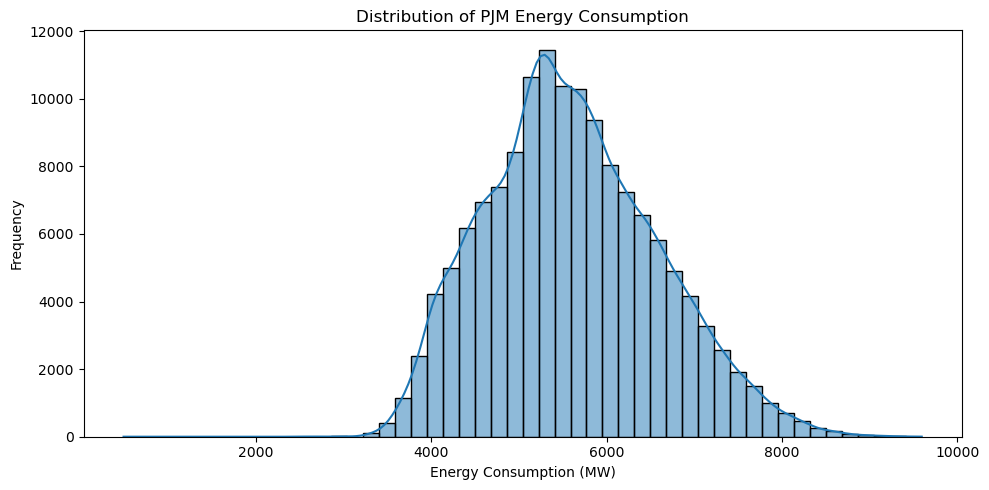

In [26]:
#Plotting the histogram for the (Frequency/Energy Consumption (MW))
plt.figure(figsize=(10, 5))

sns.histplot(
    df["PJMW_MW"],
    bins=50,
    kde=True
)

plt.title("Distribution of PJM Energy Consumption")
plt.xlabel("Energy Consumption (MW)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()


#### INFERENCE:
The PJM energy consumption distribution is unimodal and slightly right-skewed. Most observations are concentrated around 4,000 to 7,000 MW, with peak frequency around 5,000–5,500 MW. Extremely high and low consumption values occur less frequently.”

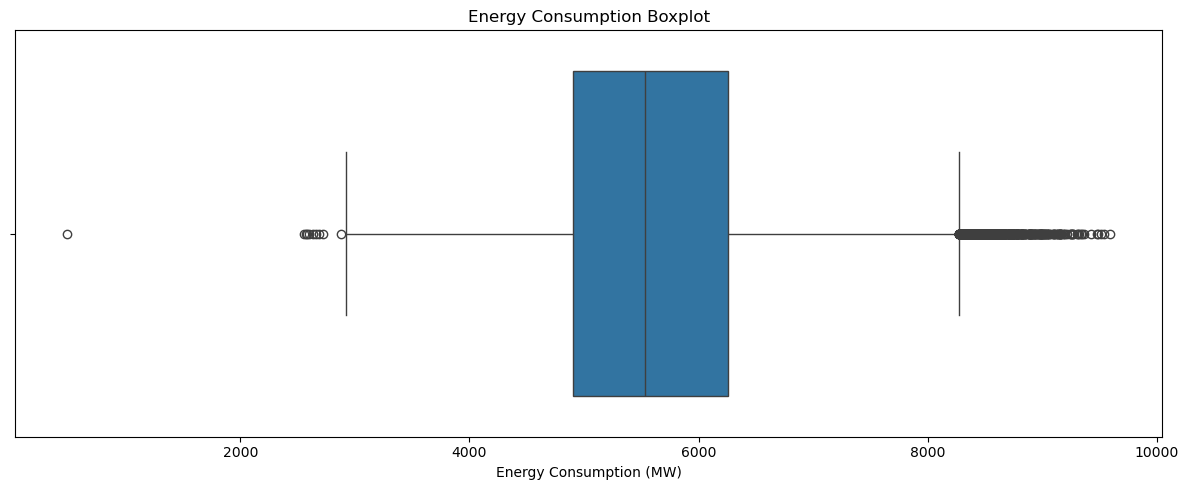

In [27]:
##Plotting the Boxplot for (Energy Consumption (MW))
plt.figure(figsize=(12, 5))

sns.boxplot(
    x=df["PJMW_MW"]
)

plt.title("Energy Consumption Boxplot")
plt.xlabel("Energy Consumption (MW)")

plt.tight_layout()
plt.show()


### INFERENCE:
The boxplot shows that PJM energy consumption is mainly concentrated between approximately 4,800 and 6,300 MW, with a median around 5,500 MW. There are several potential outliers, particularly on the higher side, indicating periods of unusually high energy consumption. A few low-end outliers are also present. These extreme values should be investigated to determine whether they represent genuine peak-demand periods or data anomalies.

### Outlier Analysis and Treatment

In [28]:
#OUTLIER DETEECTION USING THE (IQR).
#Calculates the first and third quartile(25th percentile, 75th percentile)
Q1 = df["PJMW_MW"].quantile(0.25)
Q3 = df["PJMW_MW"].quantile(0.75)

#Calculates the interquartile Range.
IQR = Q3 - Q1

#Calculates the lower and upper limits for detecting outliers.
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

#Identify observations below the lower bound  or above the upper bound as potential outliers.
outliers = df[
    (df["PJMW_MW"] < lower_bound) |
    (df["PJMW_MW"] > upper_bound)
]

#Displays the calculated outliers boundries.
print("\nIQR Lower Bound:", lower_bound)
print("IQR Upper Bound:", upper_bound)

#Displays the number of potential outliers.
print("Potential Outliers:", len(outliers))



IQR Lower Bound: 2885.5
IQR Upper Bound: 8273.5
Potential Outliers: 695


###Outlier Treatment:
Potential outliers were identified using the IQR method. Since electricity consumption can naturally exhibit high-demand and low-demand periods, these observations were retained because extreme values may represent genuine peak demand rather than data errors.

#### INFERENCE:
The IQR method was used to identify potential outliers in PJM energy consumption. The observations outside the calculated lower and upper bounds are flagged as potential outliers. These values may represent periods of unusually high or low electricity demand, so they should be investigated rather than removed automatically.

### ADF TEST

In [29]:
## ADF Stationarity Test

In [30]:
from statsmodels.tsa.stattools import adfuller

# Augmented Dickey-Fuller test
adf_result = adfuller(df["PJMW_MW"].dropna())

print("ADF Statistic:", adf_result[0])
print("p-value:", adf_result[1])
print("Number of Lags Used:", adf_result[2])
print("Number of Observations Used:", adf_result[3])

if adf_result[1] <= 0.05:
    print("\nResult: The series is stationary.")
else:
    print("\nResult: The series is non-stationary.")

ADF Statistic: -19.88105663738784
p-value: 0.0
Number of Lags Used: 74
Number of Observations Used: 142959

Result: The series is stationary.


## **Time-Series Stationarity Analysis**

### ACF Analysis

<Figure size 1200x500 with 0 Axes>

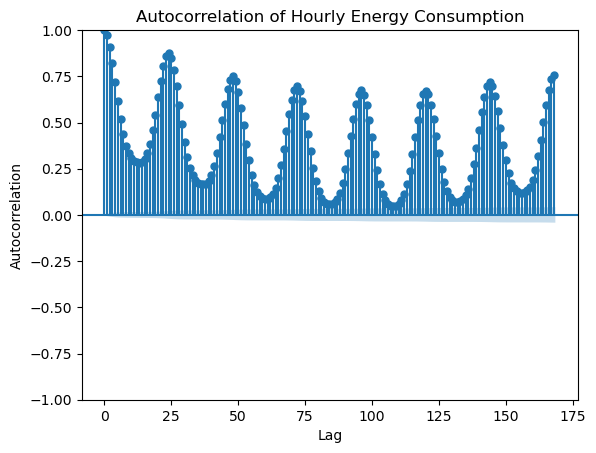

In [31]:
#importing the plot_acf from statsmodels.graphics.tsaplots
from statsmodels.graphics.tsaplots import plot_acf

plt.figure(figsize=(12, 5))

plot_acf(
    df["PJMW_MW"].dropna(),
    lags=168
)

plt.title("Autocorrelation of Hourly Energy Consumption")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

### PACF Analysis

<Figure size 1200x500 with 0 Axes>

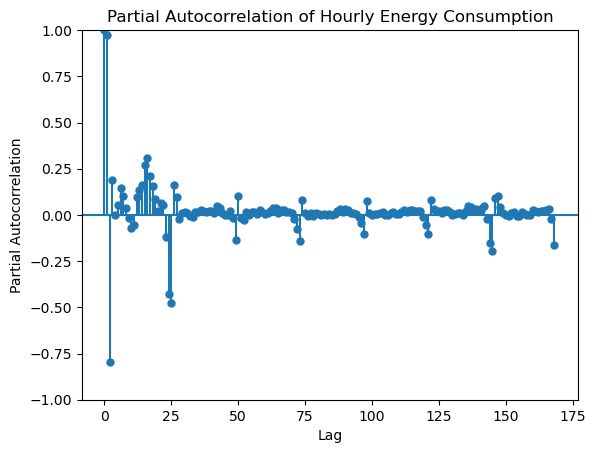

In [32]:
from statsmodels.graphics.tsaplots import plot_pacf

plt.figure(figsize=(12, 5))

plot_pacf(
    df["PJMW_MW"].dropna(),
    lags=168,
    method="ywm"
)

plt.title("Partial Autocorrelation of Hourly Energy Consumption")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

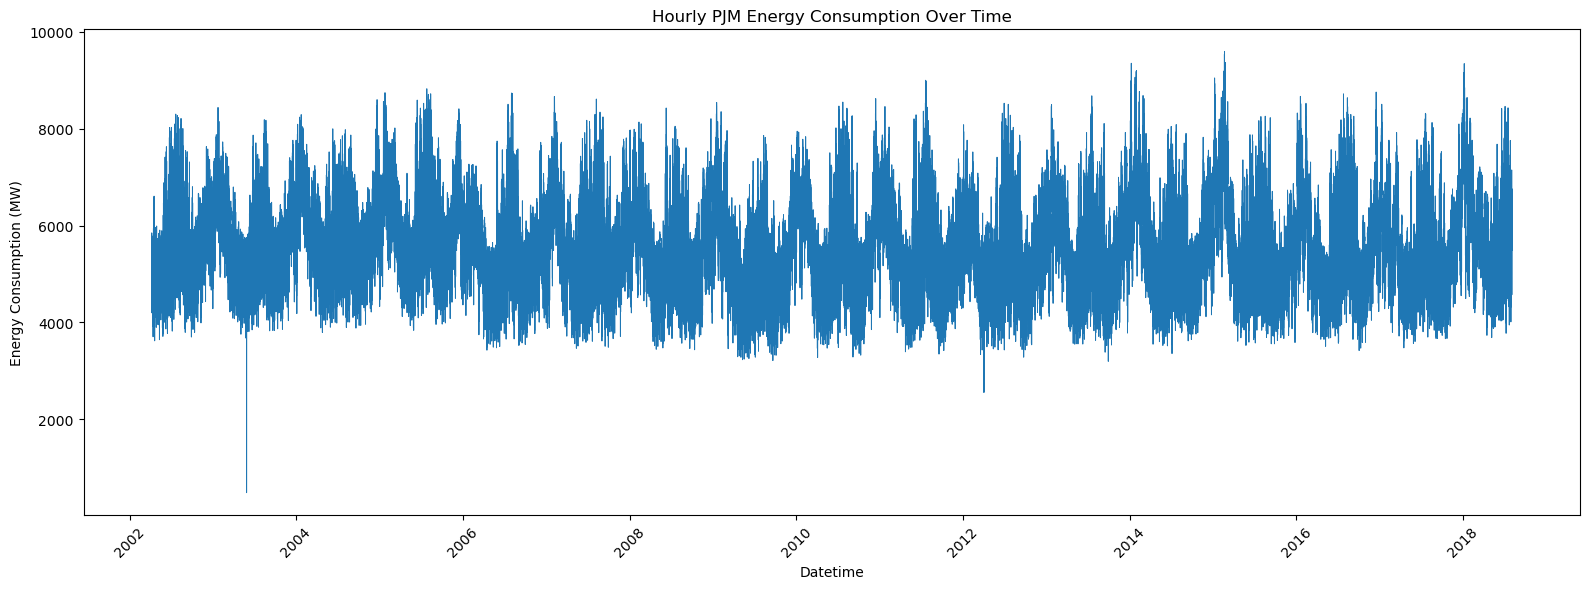

In [33]:
#plotting the time series  line plot.
plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime"],
    df["PJMW_MW"],
    linewidth=0.7
)

plt.title("Hourly PJM Energy Consumption Over Time")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()


### INFERENCE:
The time-series plot shows that PJM energy consumption has a clear recurring pattern with frequent fluctuations throughout the period. Consumption generally ranges between approximately 4,000 and 8,000 MW, with occasional peaks reaching around 9,000–10,000 MW. The repeated patterns suggest strong seasonal and daily variations in electricity demand. Overall, there is no clear long-term upward or downward trend, while some extreme peaks and dips indicate periods of unusually high or low consumption.


Average Consumption by Hour:


,Average_Consumption_MW
Hour,
0,5230.544631
1,4940.632718
2,4779.598084
3,4697.112363
4,4672.453447
5,4734.841973
6,4958.053682
7,5323.287032
8,5571.048314


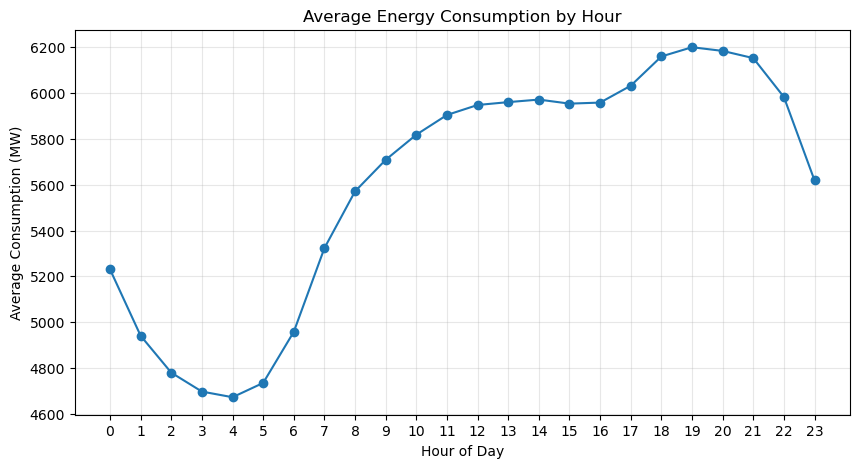

In [34]:
#Hourly average energy consumption plot.
hourly_avg = (
    df.groupby("Hour")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Hour:")
display(
    hourly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    hourly_avg.index,
    hourly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Average Consumption (MW)")

plt.xticks(range(24))
plt.grid(True, alpha=0.3)

plt.show()


### INDERENCE:
The plot shows a clear daily pattern in energy consumption. Consumption is lowest during the early morning hours, reaching its minimum around 4 AM. It then steadily increases through the morning and reaches a high level during the afternoon and evening. The peak occurs around 7–8 PM, after which consumption decreases, with a noticeable drop during the late evening. This indicates strong daily/diurnal seasonality in electricity demand.


Average Consumption by Day:


,Average_Consumption_MW
Day_Name,
Monday,5701.098063
Tuesday,5801.652729
Wednesday,5802.929920
Thursday,5780.970217
Friday,5686.840041
Saturday,5293.912701
Sunday,5149.935870


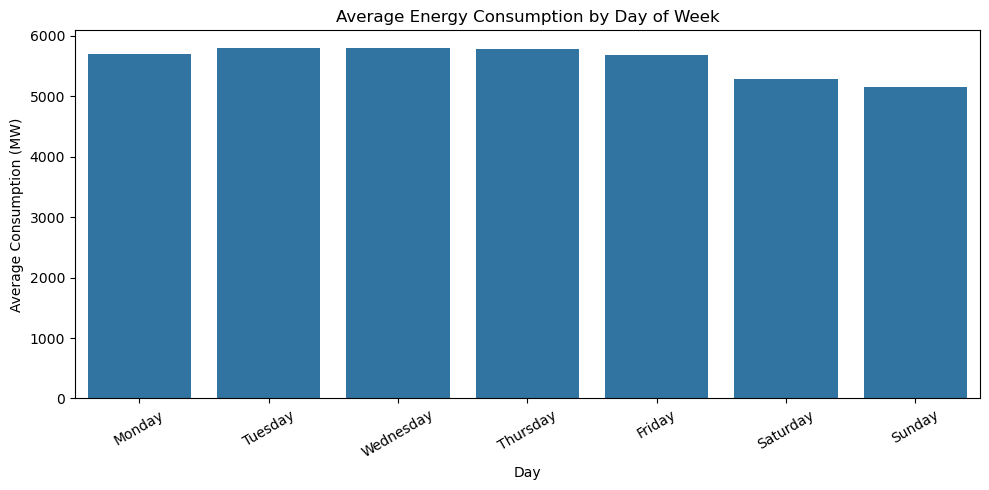

In [35]:
#Plotting bar chart for average PJM energy consumption by day of the week.
day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
    "Saturday",
    "Sunday"
]

day_avg = (
    df.groupby("Day_Name")["PJMW_MW"]
    .mean()
    .reindex(day_order)
)

print("\nAverage Consumption by Day:")
display(
    day_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

sns.barplot(
    x=day_avg.index,
    y=day_avg.values
)

plt.title("Average Energy Consumption by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average Consumption (MW)")

plt.xticks(rotation=30)
plt.tight_layout()

plt.show()


### INFERENCE:
The chart shows that average energy consumption is relatively consistent from Monday to Friday, with Wednesday and Thursday having slightly higher consumption. Consumption decreases noticeably on Saturday and Sunday. This indicates a weekly pattern, where energy demand is generally higher on weekdays and lower during weekends.

Weekday Average: 5754.7151760032875
Weekend Average: 5221.973664870162


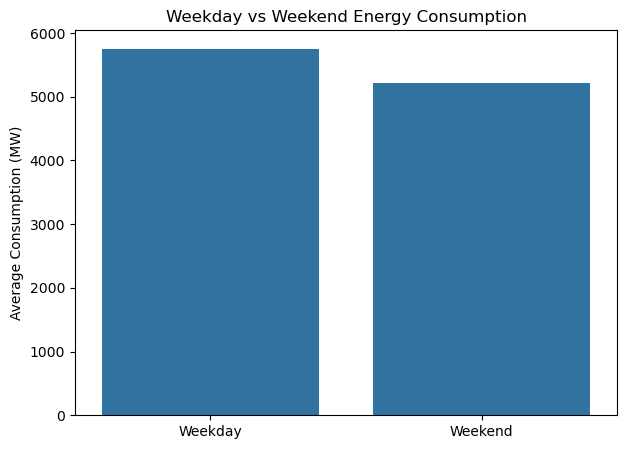

In [36]:
#plotting Comparission plot by bar chart.
weekend_avg = (
    df.groupby("Weekend")["PJMW_MW"]
    .mean()
)

print(
    "Weekday Average:",
    weekend_avg.get(False, np.nan)
)

print(
    "Weekend Average:",
    weekend_avg.get(True, np.nan)
)

plt.figure(figsize=(7, 5))

sns.barplot(
    x=["Weekday", "Weekend"],
    y=[
        weekend_avg.get(False, np.nan),
        weekend_avg.get(True, np.nan)
    ]
)

plt.title("Weekday vs Weekend Energy Consumption")
plt.ylabel("Average Consumption (MW)")

plt.show()


### INFERENCE:
The chart shows that average energy consumption is higher on weekdays, at approximately 5,750 MW, compared with around 5,200 MW on weekends. This indicates that electricity demand is higher during weekdays and decreases during weekends, showing a clear weekday–weekend consumption pattern.


Average Consumption by Month:


,Average_Consumption_MW
Month,
1,6447.667759
2,6296.808813
3,5654.097376
4,5017.339798
5,5015.845746
6,5516.756046
7,5861.537081
8,5822.142809
9,5205.872049


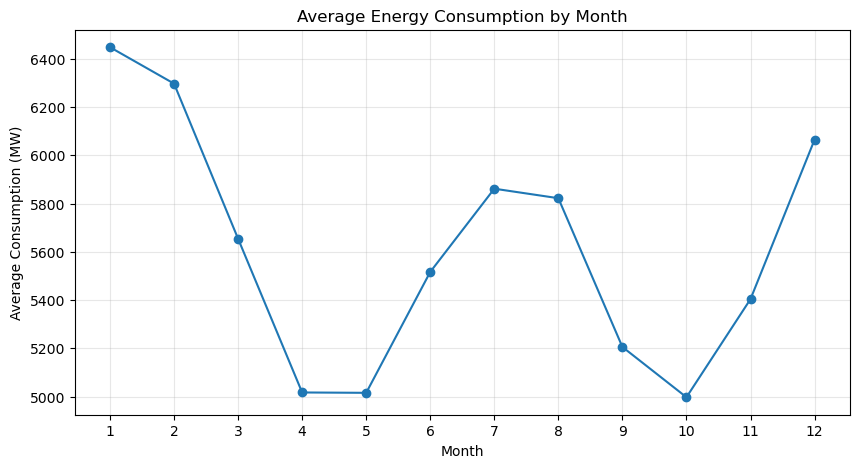

In [37]:
monthly_avg = (
    df.groupby("Month")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Month:")
display(
    monthly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Month")
plt.xlabel("Month")
plt.ylabel("Average Consumption (MW)")

plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)

plt.show()


### INFERNEC:
Energy consumption varies considerably across months. It is highest in January and December, while it reaches lower levels around April–May and October, indicating a clear monthly/seasonal pattern in electricity demand.


Average Consumption by Year:


,Average_Consumption_MW
Year,
2002,5627.995489
2003,5700.628226
2004,5866.616602
2005,6038.406029
2006,5425.448847
2007,5635.396780
2008,5530.132544
2009,5290.557433
2010,5573.025351


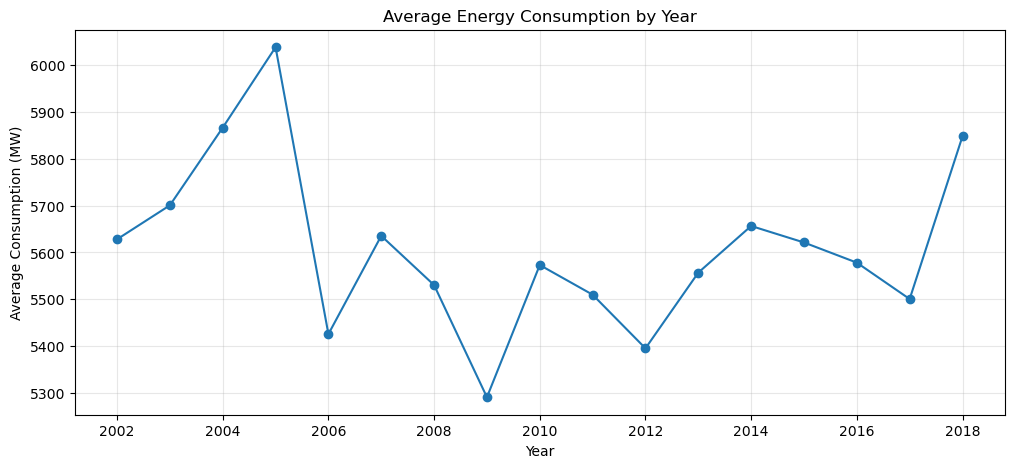

In [38]:


yearly_avg = (
    df.groupby("Year")["PJMW_MW"]
    .mean()
)

print("\nAverage Consumption by Year:")
display(
    yearly_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(12, 5))

plt.plot(
    yearly_avg.index,
    yearly_avg.values,
    marker="o"
)

plt.title("Average Energy Consumption by Year")
plt.xlabel("Year")
plt.ylabel("Average Consumption (MW)")

plt.grid(True, alpha=0.3)

plt.show()

#### INFERENCE:
The yearly average shows noticeable fluctuations rather than a consistent upward or downward trend. Consumption peaks around 2005, declines afterward, and fluctuates through the later years, with an increase again in 2018.


Average Consumption by Season:


,Average_Consumption_MW
Season,
Winter,6268.813851
Spring,5223.683686
Summer,5734.206129
Autumn,5200.264085


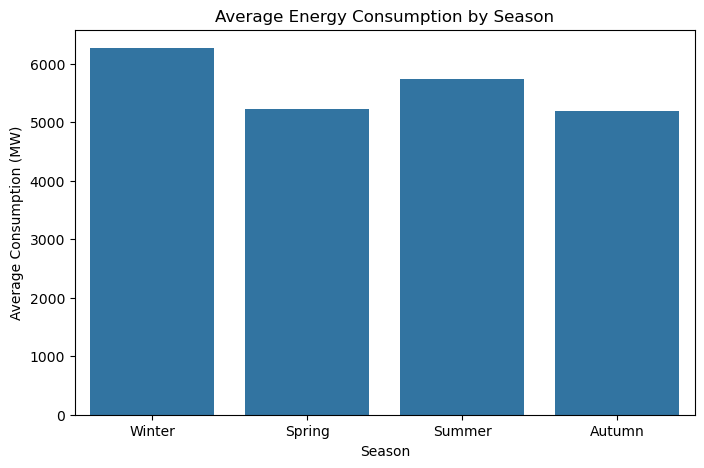

In [39]:

season_order = [
    "Winter",
    "Spring",
    "Summer",
    "Autumn"
]

season_avg = (
    df.groupby("Season")["PJMW_MW"]
    .mean()
    .reindex(season_order)
)

print("\nAverage Consumption by Season:")
display(
    season_avg.to_frame(
        "Average_Consumption_MW"
    )
)

plt.figure(figsize=(8, 5))

sns.barplot(
    x=season_avg.index,
    y=season_avg.values
)

plt.title("Average Energy Consumption by Season")
plt.xlabel("Season")
plt.ylabel("Average Consumption (MW)")

plt.show()


#### INFERENCE:
Winter has the highest average energy consumption, followed by summer. Spring and autumn show comparatively lower consumption. This indicates that seasonal conditions have a significant influence on electricity demand.

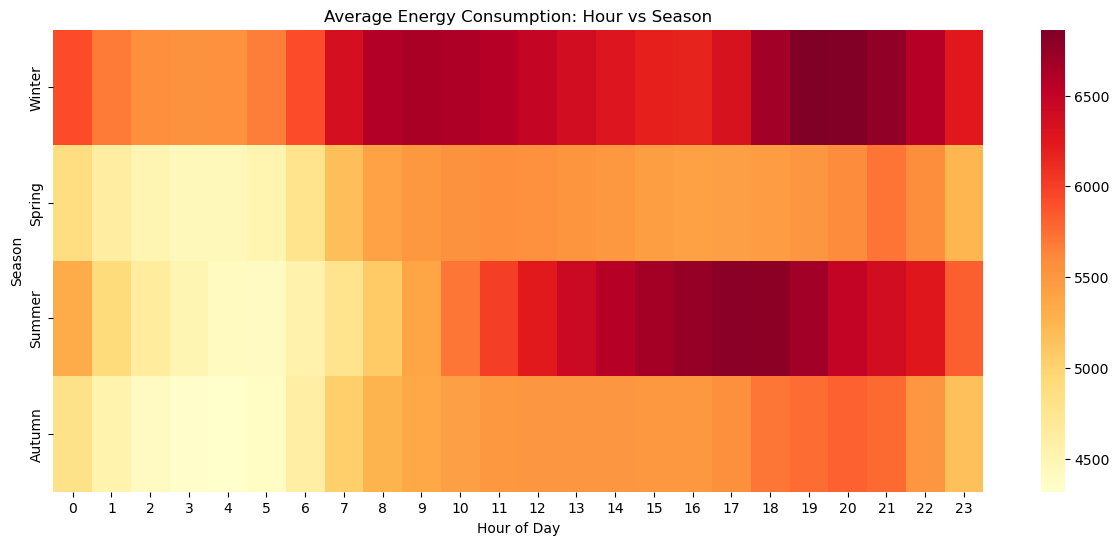

In [40]:
hour_season = df.pivot_table(
    values="PJMW_MW",
    index="Season",
    columns="Hour",
    aggfunc="mean"
)

hour_season = hour_season.reindex(
    season_order
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    hour_season,
    cmap="YlOrRd"
)

plt.title(
    "Average Energy Consumption: Hour vs Season"
)

plt.xlabel("Hour of Day")
plt.ylabel("Season")

plt.show()


#### INFERENCE:
Energy consumption varies by both hour of the day and season. Winter generally shows higher consumption, particularly during later hours, while spring and autumn have relatively lower levels. This indicates an interaction between seasonal and daily demand patterns.

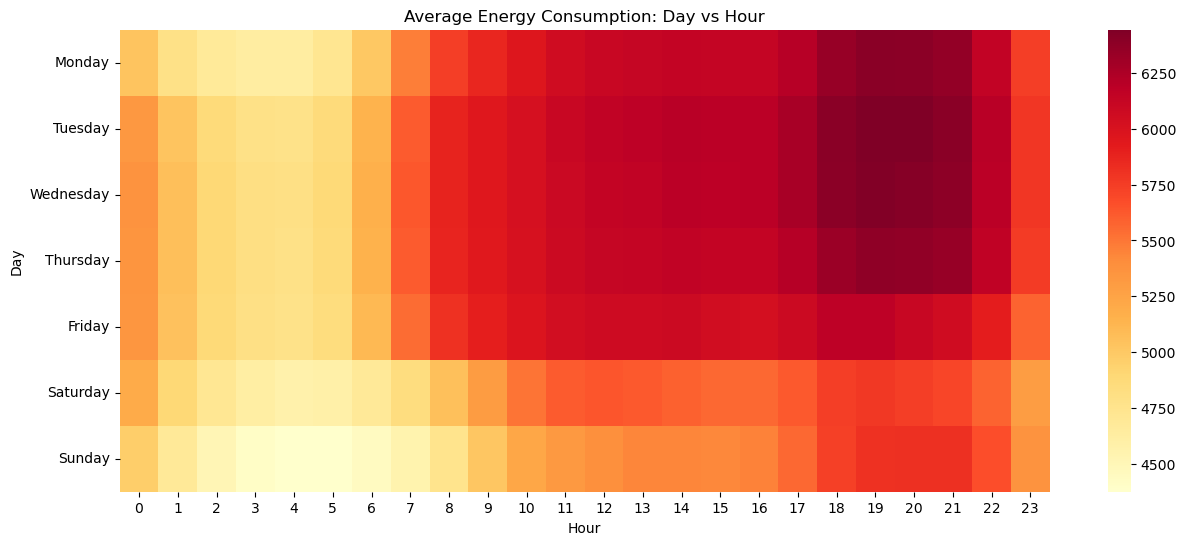

In [41]:
day_hour = df.pivot_table(
    values="PJMW_MW",
    index="Day_Name",
    columns="Hour",
    aggfunc="mean"
)

day_hour = day_hour.reindex(
    day_order
)

plt.figure(figsize=(15, 6))

sns.heatmap(
    day_hour,
    cmap="YlOrRd"
)

plt.title(
    "Average Energy Consumption: Day vs Hour"
)

plt.xlabel("Hour")
plt.ylabel("Day")
plt.show()

### INFERENCE:
Energy consumption is generally lower during the early morning hours and increases from around 7–8 AM. It remains high throughout the daytime and evening, with particularly high consumption on weekdays. Weekend consumption is comparatively lower.

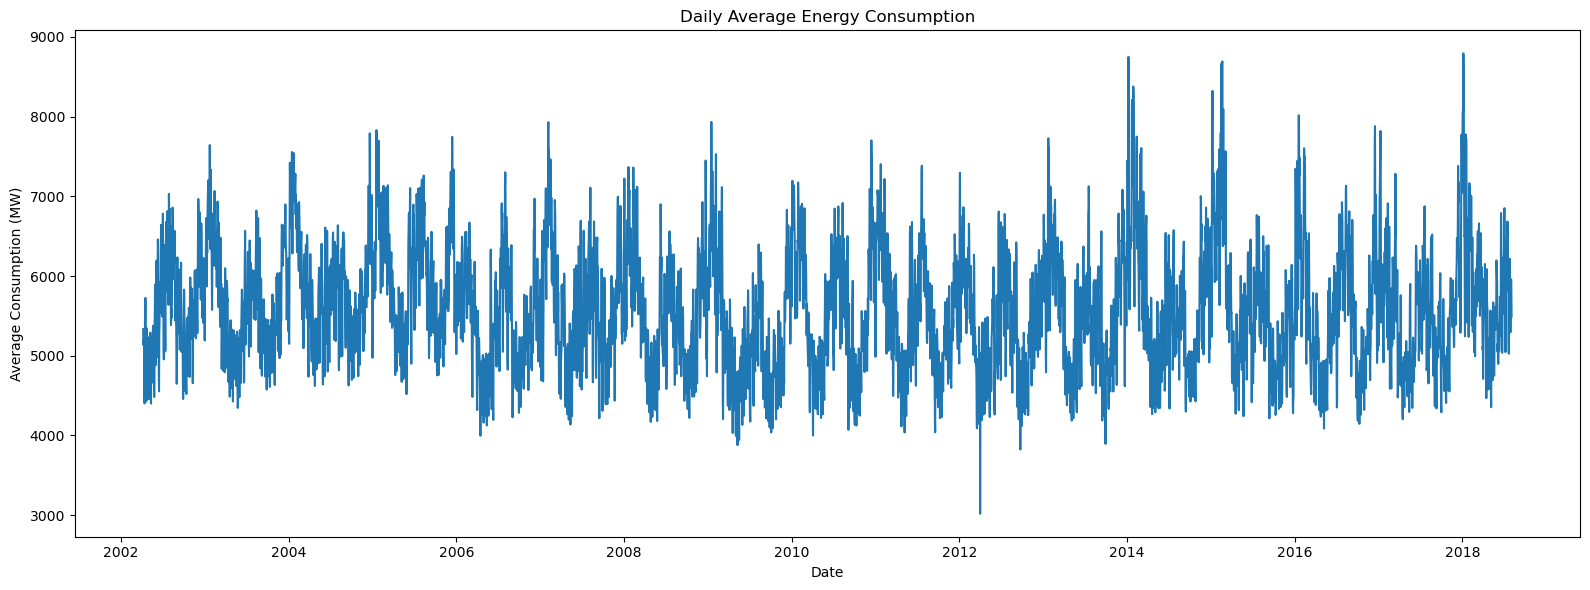

In [42]:
daily_avg = (
    df.set_index("Datetime")["PJMW_MW"]
    .resample("D")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    daily_avg.index,
    daily_avg.values
)

plt.title("Daily Average Energy Consumption")
plt.xlabel("Date")
plt.ylabel("Average Consumption (MW)")

plt.tight_layout()
plt.show()


#### INFERENCE:
Daily consumption shows substantial short-term fluctuations throughout the period. The series repeatedly rises and falls, with occasional high peaks and low values, indicating strong daily variability and recurring patterns in energy demand.

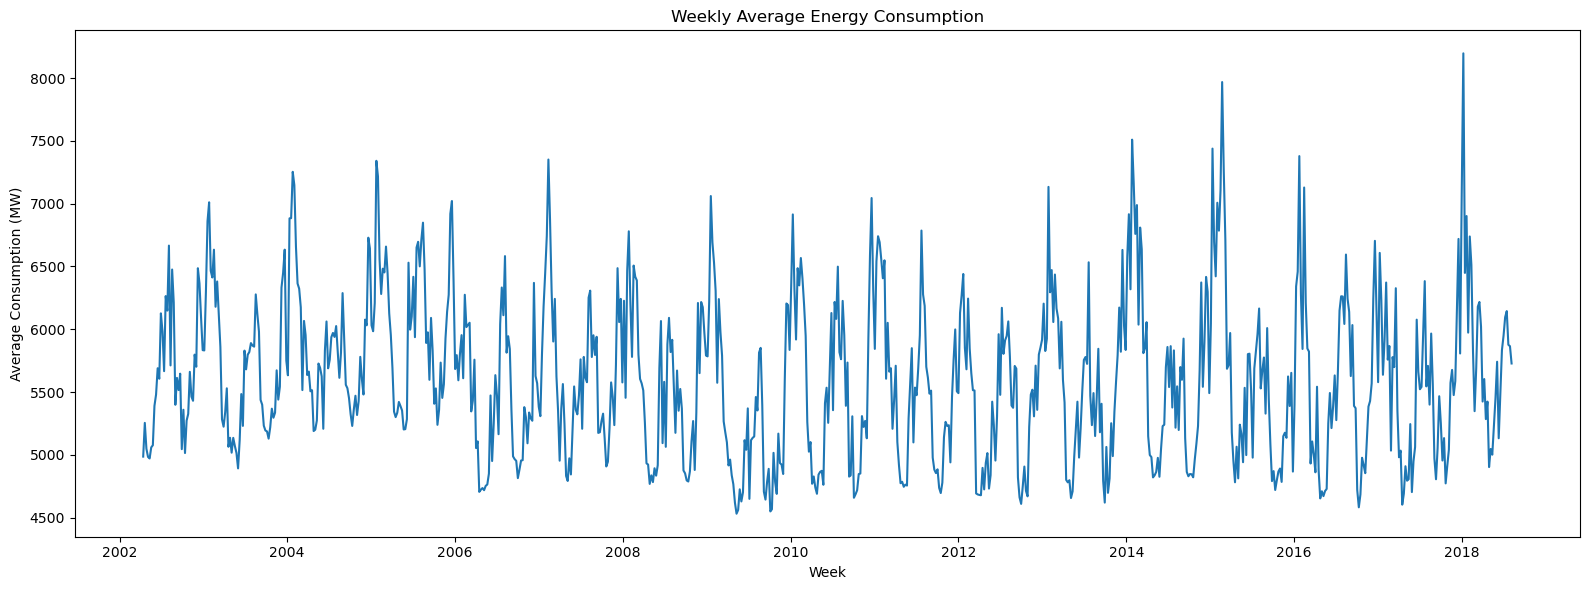

In [43]:
weekly_avg = (
    df.set_index("Datetime")["PJMW_MW"]
    .resample("W")
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    weekly_avg.index,
    weekly_avg.values
)

plt.title("Weekly Average Energy Consumption")
plt.xlabel("Week")
plt.ylabel("Average Consumption (MW)")

plt.tight_layout()
plt.show()

#### INFERENCE:
Weekly consumption also shows recurring fluctuations, with regular peaks and troughs. The overall level remains relatively stable across the years, suggesting repeating weekly patterns rather than a strong long-term trend.

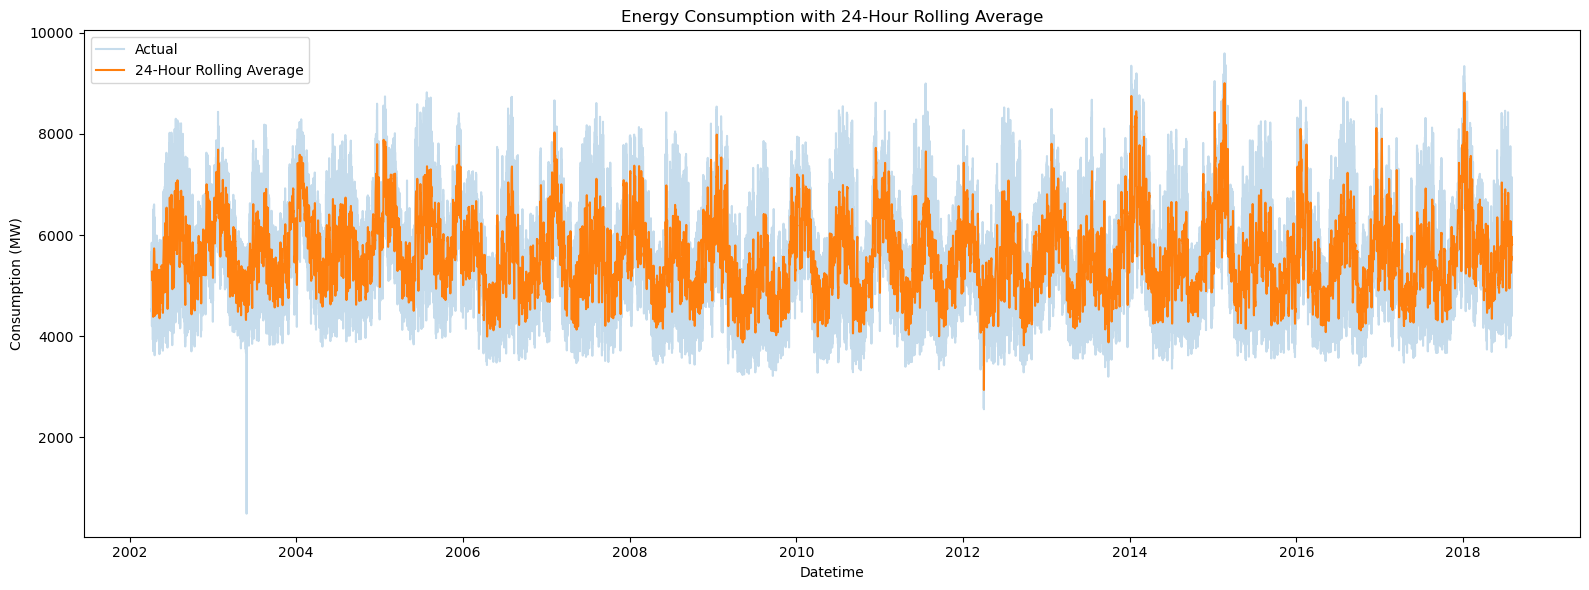

In [44]:
# Creating leakage-safe rolling averages for visualization

rolling_24h_plot = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(24)
    .mean()
)

rolling_7d_plot = (
    df["PJMW_MW"]
    .shift(1)
    .rolling(168)
    .mean()
)

plt.figure(figsize=(16, 6))

plt.plot(
    df["Datetime"],
    df["PJMW_MW"],
    alpha=0.25,
    label="Actual"
)

plt.plot(
    df["Datetime"],
    rolling_24h_plot,
    label="24-Hour Rolling Average"
)

plt.title("Energy Consumption with 24-Hour Rolling Average")
plt.xlabel("Datetime")
plt.ylabel("Consumption (MW)")
plt.legend()

plt.tight_layout()
plt.show()

#### INFERENCE:
The 24-hour rolling average smooths the short-term fluctuations in actual energy consumption. It clearly reveals the underlying consumption pattern while reducing the effect of individual hourly peaks and drops. This can be useful for identifying the general trend before forecasting.

In [45]:
df["Lag_1_Hour"] = df["PJMW_MW"].shift(1)
df["Lag_24_Hours"] = df["PJMW_MW"].shift(24)
df["Lag_48_Hours"] = df["PJMW_MW"].shift(48)
df["Lag_168_Hours"] = df["PJMW_MW"].shift(168)

lag_columns = [
    "PJMW_MW",
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours"
]

print("\nLag Correlations:")
display(
    df[lag_columns].corr()
)



Lag Correlations:


,PJMW_MW,Lag_1_Hour,Lag_24_Hours,Lag_48_Hours,Lag_168_Hours
PJMW_MW,1.000000,0.974691,0.877210,0.750437,0.759371
Lag_1_Hour,0.974691,1.000000,0.860024,0.732817,0.737791
Lag_24_Hours,0.877210,0.860024,1.000000,0.877198,0.719295
Lag_48_Hours,0.750437,0.732817,0.877198,1.000000,0.673040
Lag_168_Hours,0.759371,0.737791,0.719295,0.673040,1.000000


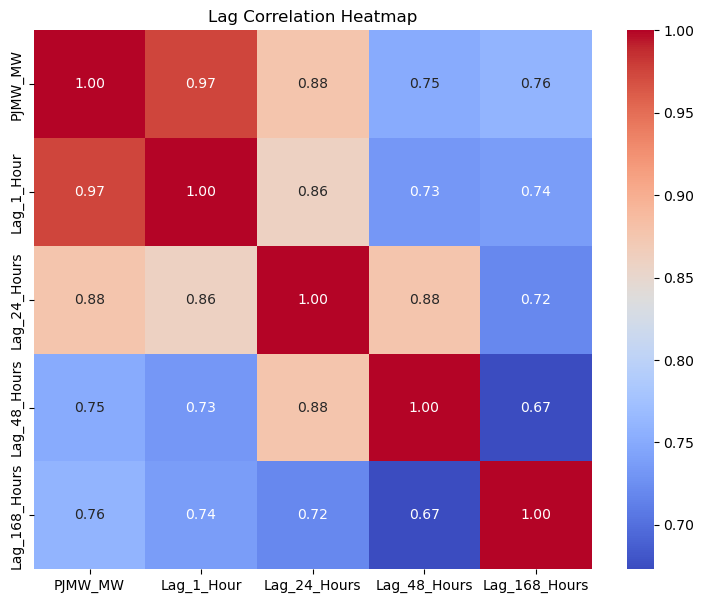

In [46]:
plt.figure(figsize=(9, 7))

sns.heatmap(
    df[lag_columns].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Lag Correlation Heatmap")

plt.show()



#### INFERENCE:
The heatmap shows strong positive correlations between current consumption and lagged consumption. The correlation is highest for shorter lags, such as 1 hour (0.97), and gradually decreases for longer lags, reaching around 0.76 at 168 hours. This indicates strong temporal dependence and suggests that previous energy consumption values can be useful predictors for forecasting.

In [47]:
#Final Feature Selection.
features = [
    "Year",
    "Month",
    "Day",
    "Hour",
    "Day_of_Week",
    "Quarter",
    "Week",
    "Weekend",
    "Lag_1_Hour",
    "Lag_24_Hours",
    "Lag_48_Hours",
    "Lag_168_Hours",
    "Rolling_24H",
    "Rolling_7D"
]

X = df[features]
y = df["PJMW_MW"]

print("Feature shape:", X.shape)
print("Target shape:", y.shape)

Feature shape: (143034, 14)
Target shape: (143034,)


In [48]:
# Chronological train-test split

train_size = int(len(df) * 0.80)

X_train = X.iloc[:train_size]
X_test = X.iloc[train_size:]

y_train = y.iloc[:train_size]
y_test = y.iloc[train_size:]

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

print("\nTraining period:")
print(df["Datetime"].iloc[:train_size].min())
print("to")
print(df["Datetime"].iloc[train_size - 1])

print("\nTesting period:")
print(df["Datetime"].iloc[train_size])
print("to")
print(df["Datetime"].iloc[-1])

Training data: (114427, 14)
Testing data: (28607, 14)

Training period:
2002-04-08 02:00:00
to
2015-04-28 22:00:00

Testing period:
2015-04-28 23:00:00
to
2018-08-03 00:00:00


#### Scaling the Features.

In [49]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Scaled training shape:", X_train_scaled.shape)
print("Scaled testing shape:", X_test_scaled.shape)

Scaled training shape: (114427, 14)
Scaled testing shape: (28607, 14)


# Model Building

## ARIMA and SARIMA Model Building
The models use the daily-average time series `daily_avg` prepared during the EDA stage.

The original PJM dataset contains hourly observations. However, the EDA stage has already prepared a daily-average series. Therefore, the modeling stage uses this existing EDA-prepared series.


In [50]:
# ============================================================
# ARIMA / SARIMA MODELING - IMPORTS
# ============================================================

import itertools
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

warnings.filterwarnings("ignore")

print("Libraries imported successfully.")

Libraries imported successfully.


In [51]:
# ============================================================
# USE EDA-PREPARED DAILY SERIES
# ============================================================
# Use the daily-average series already created during EDA.

daily = daily_avg.copy()

# Ensure chronological ordering
daily.index = pd.to_datetime(daily.index)
daily = daily.sort_index()

print("EDA-prepared modelling series:")
display(daily.head())

print("\nData type:")
print(type(daily))

print("\nNumber of observations:")
print(len(daily))

print("\nStart date:")
print(daily.index.min())

print("\nEnd date:")
print(daily.index.max())

print("\nMissing values:")
print(daily.isna().sum())

EDA-prepared modelling series:


Datetime
2002-04-08    5335.500000
2002-04-09    5136.083333
2002-04-10    5171.666667
2002-04-11    5207.875000
2002-04-12    5090.416667
Freq: D, Name: PJMW_MW, dtype: float64


Data type:
<class 'pandas.core.series.Series'>

Number of observations:
5962

Start date:
2002-04-08 00:00:00

End date:
2018-08-03 00:00:00

Missing values:
0


In [52]:
# ============================================================
# VERIFY MODELING FREQUENCY
# ============================================================

time_difference = (
    daily.index.to_series()
    .diff()
    .dropna()
)

print("Most common time interval:")
print(time_difference.mode().iloc[0])

print("\nTime interval counts:")
display(
    time_difference.value_counts().head()
)

print("\nInferred frequency:")
print(pd.infer_freq(daily.index))

Most common time interval:
1 days 00:00:00

Time interval counts:


Datetime
1 days    5961
Name: count, dtype: int64


Inferred frequency:
D


## Modeling Frequency

The original PJM energy consumption data is hourly.

However, the EDA stage already created the `daily_avg` series by calculating the daily mean consumption from the cleaned hourly data.

Therefore, ARIMA and SARIMA are developed using the EDA-prepared daily series.

For the modeling data:

- 1 observation = 1 day
- 7 observations = 1 week
- Approximately 365 observations = 1 year

The EDA identified weekly patterns in energy consumption. Therefore, the seasonal period for SARIMA is represented by 7 daily observations.

### Chronological train/test split

In [53]:

test_size = 365

train_daily = daily.iloc[:-test_size].copy()
test_daily = daily.iloc[-test_size:].copy()

print("Training observations:", len(train_daily))
print("Testing observations :", len(test_daily))

print("\nTraining period:")
print(
    train_daily.index.min(),
    "to",
    train_daily.index.max()
)

print("\nTesting period:")
print(
    test_daily.index.min(),
    "to",
    test_daily.index.max()
)

# Verify chronological order
assert train_daily.index.max() < test_daily.index.min()

print("\nChronological train-test split verified.")

Training observations: 5597
Testing observations : 365

Training period:
2002-04-08 00:00:00 to 2017-08-03 00:00:00

Testing period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

Chronological train-test split verified.


### Train/test visualization

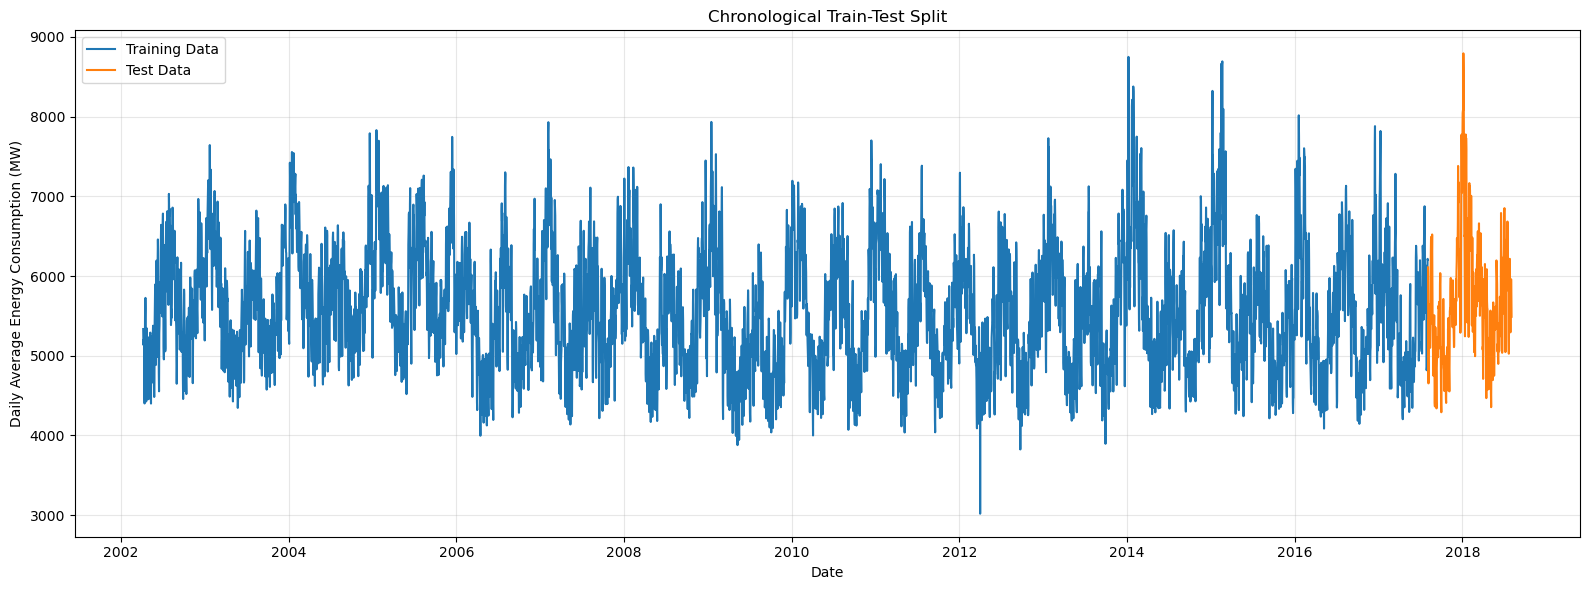

In [54]:
plt.figure(figsize=(16, 6))

plt.plot(
    train_daily.index,
    train_daily.values,
    label="Training Data"
)

plt.plot(
    test_daily.index,
    test_daily.values,
    label="Test Data"
)

plt.title(
    "Chronological Train-Test Split"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Stationarity test

ARIMA requires the time series to be stationary or transformed into a stationary series.

The Augmented Dickey-Fuller (ADF) test is used to assess stationarity.

If the p-value is less than or equal to 0.05, the null hypothesis of non-stationarity is rejected.

The differencing order `d` is selected based on the stationarity of the training series.

In [55]:
# ============================================================
# ADF STATIONARITY TEST
# ============================================================

def run_adf(series, name):

    series = series.dropna()

    result = adfuller(
        series,
        autolag="AIC"
    )

    print(f"\nADF Test: {name}")
    print("-" * 45)

    print(
        f"ADF Statistic : {result[0]:.4f}"
    )

    print(
        f"p-value       : {result[1]:.4f}"
    )

    print(
        f"Lags Used     : {result[2]}"
    )

    print(
        f"Observations  : {result[3]}"
    )

    if result[1] <= 0.05:
        print(
            "Result: The series is stationary."
        )
    else:
        print(
            "Result: The series is non-stationary."
        )

    return result[1]

In [56]:
# ============================================================
# DETERMINE ARIMA DIFFERENCING ORDER d
# ============================================================

p_level = run_adf(
    train_daily,
    "Original Training Series"
)

p_first_diff = run_adf(
    train_daily.diff(),
    "First-Differenced Training Series"
)

if p_level <= 0.05:
    d = 0
else:
    d = 1

print("\nSelected ARIMA differencing order:")
print("d =", d)


ADF Test: Original Training Series
---------------------------------------------
ADF Statistic : -7.1489
p-value       : 0.0000
Lags Used     : 33
Observations  : 5563
Result: The series is stationary.

ADF Test: First-Differenced Training Series
---------------------------------------------
ADF Statistic : -16.4174
p-value       : 0.0000
Lags Used     : 32
Observations  : 5563
Result: The series is stationary.

Selected ARIMA differencing order:
d = 0


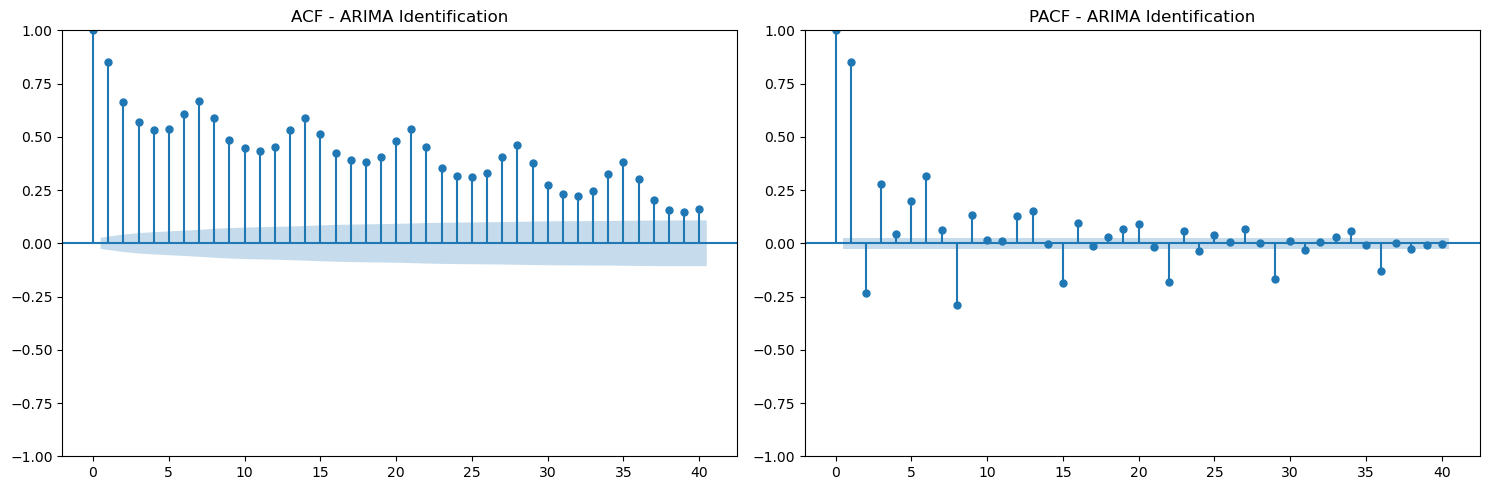

In [57]:
# ============================================================
# ACF / PACF FOR ARIMA IDENTIFICATION
# ============================================================

if d == 1:
    arima_identification_series = (
        train_daily.diff().dropna()
    )
else:
    arima_identification_series = train_daily.copy()

fig, axes = plt.subplots(
    1,
    2,
    figsize=(15, 5)
)

plot_acf(
    arima_identification_series,
    lags=40,
    ax=axes[0]
)

plot_pacf(
    arima_identification_series,
    lags=40,
    method="ywm",
    ax=axes[1]
)

axes[0].set_title(
    "ACF - ARIMA Identification"
)

axes[1].set_title(
    "PACF - ARIMA Identification"
)

plt.tight_layout()
plt.show()

## ARIMA Parameter Selection

ARIMA is represented as:

ARIMA(p,d,q)

where:

- `p` = autoregressive order
- `d` = differencing order
- `q` = moving-average order

The ADF test is used to determine `d`.

The ACF and PACF plots provide initial guidance for possible values of `p` and `q`.

However, the final `p` and `q` values are selected through systematic hyperparameter tuning using AIC.

## ARIMA hyperparameter tuning

In [58]:
# ============================================================
# ARIMA HYPERPARAMETER TUNING
# ============================================================

p_values = range(0, 4)
q_values = range(0, 4)

arima_results = []

start_time = time.time()

for p, q in itertools.product(
    p_values,
    q_values
):

    order = (
        p,
        d,
        q
    )

    try:

        model = ARIMA(
            train_daily,
            order=order
        )

        fitted_model = model.fit()

        arima_results.append({
            "p": p,
            "d": d,
            "q": q,
            "order": order,
            "AIC": fitted_model.aic
        })

    except Exception as e:

        print(
            f"ARIMA{order} failed: {e}"
        )


arima_table = (
    pd.DataFrame(arima_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

elapsed_time = (
    time.time() - start_time
) / 60

print(
    f"ARIMA tuning completed in "
    f"{elapsed_time:.2f} minutes."
)

print("\nARIMA hyperparameter results:")

display(arima_table)

ARIMA tuning completed in 0.80 minutes.

ARIMA hyperparameter results:


,p,d,q,order,AIC
0,3,0,3,"(3, 0, 3)",81371.404756
1,2,0,3,"(2, 0, 3)",81416.521570
2,1,0,3,"(1, 0, 3)",81416.626591
3,3,0,1,"(3, 0, 1)",81453.288088
4,2,0,2,"(2, 0, 2)",81460.167248
5,3,0,2,"(3, 0, 2)",81478.704256
6,1,0,2,"(1, 0, 2)",81747.689112
7,3,0,0,"(3, 0, 0)",81753.081860
8,2,0,1,"(2, 0, 1)",81901.814679
9,1,0,1,"(1, 0, 1)",81942.176500


### SELECT BEST ARIMA MODEL

In [59]:
best_arima_order = (
    arima_table.loc[0, "order"]
)

best_arima_aic = (
    arima_table.loc[0, "AIC"]
)

print(
    "Best ARIMA order selected by AIC:"
)

print(
    best_arima_order
)

print(
    "\nBest ARIMA AIC:"
)

print(
    best_arima_aic
)

Best ARIMA order selected by AIC:
(3, 0, 3)

Best ARIMA AIC:
81371.40475607156


### TOP ARIMA MODELS

In [60]:
print("Top 10 ARIMA models:")

display(
    arima_table.head(10)
)

Top 10 ARIMA models:


,p,d,q,order,AIC
0,3,0,3,"(3, 0, 3)",81371.404756
1,2,0,3,"(2, 0, 3)",81416.521570
2,1,0,3,"(1, 0, 3)",81416.626591
3,3,0,1,"(3, 0, 1)",81453.288088
4,2,0,2,"(2, 0, 2)",81460.167248
5,3,0,2,"(3, 0, 2)",81478.704256
6,1,0,2,"(1, 0, 2)",81747.689112
7,3,0,0,"(3, 0, 0)",81753.081860
8,2,0,1,"(2, 0, 1)",81901.814679
9,1,0,1,"(1, 0, 1)",81942.176500


## Final ARIMA model

In [61]:
# ============================================================
# FINAL ARIMA MODEL
# ============================================================

arima_fit = ARIMA(
    train_daily,
    order=best_arima_order
).fit()

print(
    "Final ARIMA model fitted successfully."
)

print(
    "\nSelected ARIMA order:"
)

print(
    best_arima_order
)

print(
    "\nFinal ARIMA AIC:"
)

print(
    arima_fit.aic
)

Final ARIMA model fitted successfully.

Selected ARIMA order:
(3, 0, 3)

Final ARIMA AIC:
81371.40475607156


In [62]:
print(arima_fit.summary())

                               SARIMAX Results                                
Dep. Variable:                PJMW_MW   No. Observations:                 5597
Model:                 ARIMA(3, 0, 3)   Log Likelihood              -40677.702
Date:                Tue, 29 Sep 2026   AIC                          81371.405
Time:                        13:34:30   BIC                          81424.445
Sample:                    04-08-2002   HQIC                         81389.889
                         - 08-03-2017                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       5596.2625     71.351     78.432      0.000    5456.416    5736.109
ar.L1          1.9445      0.063     30.854      0.000       1.821       2.068
ar.L2         -1.3733      0.084    -16.317      0.0

### ARIMA TEST-PERIOD FORECAST

In [63]:
arima_test_result = (
    arima_fit.get_forecast(
        steps=len(test_daily)
    )
)

arima_test_mean = (
    arima_test_result.predicted_mean
)

arima_test_ci = (
    arima_test_result.conf_int()
)

arima_test_forecast_df = pd.DataFrame(
    {
        "Actual": test_daily.values,
        "Forecast": arima_test_mean.values,
        "Lower_CI": arima_test_ci.iloc[:, 0].values,
        "Upper_CI": arima_test_ci.iloc[:, 1].values
    },
    index=test_daily.index
)

arima_test_forecast_df.index.name = "Date"

display(
    arima_test_forecast_df.head(10)
)

,Actual,Forecast,Lower_CI,Upper_CI
Date,,,,
2017-08-04,6108.875000,5943.403927,5262.597915,6624.209940
2017-08-05,4997.000000,5741.293631,4754.252537,6728.334724
2017-08-06,4653.291667,5679.936504,4617.110670,6742.762339
2017-08-07,5245.791667,5703.916496,4624.147692,6783.685301
2017-08-08,5461.625000,5750.899404,4663.813674,6837.985133
2017-08-09,5462.750000,5783.853178,4686.897377,6880.808979
2017-08-10,5432.083333,5793.365837,4679.789302,6906.942373
2017-08-11,5647.041667,5786.113203,4650.355619,6921.870786
2017-08-12,5450.041667,5772.627709,4613.404771,6931.850648


## ARIMA TEST FORECAST VISUALIZATION

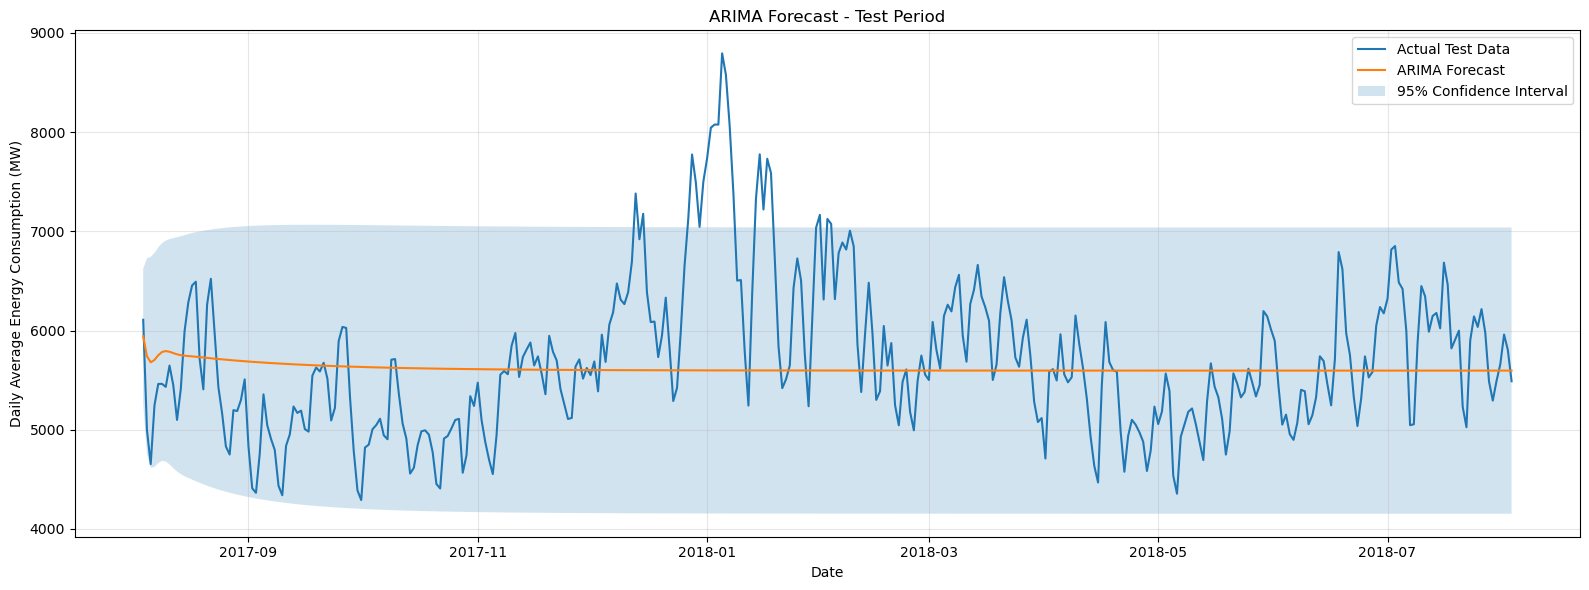

In [64]:
plt.figure(figsize=(16, 6))

plt.plot(
    test_daily.index,
    test_daily.values,
    label="Actual Test Data"
)

plt.plot(
    arima_test_forecast_df.index,
    arima_test_forecast_df["Forecast"],
    label="ARIMA Forecast"
)

plt.fill_between(
    arima_test_forecast_df.index,
    arima_test_forecast_df["Lower_CI"],
    arima_test_forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "ARIMA Forecast - Test Period"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# SARIMA Model

SARIMA extends ARIMA by explicitly modeling seasonal patterns.

The SARIMA model is represented as:

SARIMA(p,d,q)(P,D,Q,s)

where:

- `p` = regular autoregressive order
- `d` = regular differencing order
- `q` = regular moving-average order
- `P` = seasonal autoregressive order
- `D` = seasonal differencing order
- `Q` = seasonal moving-average order
- `s` = seasonal period

The EDA identified a weekly pattern in energy consumption.

Because the modeling series is daily:

1 week = 7 observations

Therefore, the SARIMA seasonal period is set to `s = 7`.

In [65]:
# ============================================================
# SARIMA SEASONAL PERIOD
# ============================================================

s = 7

print(
    "Selected SARIMA seasonal period:"
)

print(
    f"s = {s} observations"
)

print(
    "Interpretation: "
    "7 daily observations = 1 week."
)

Selected SARIMA seasonal period:
s = 7 observations
Interpretation: 7 daily observations = 1 week.


In [66]:
# ============================================================
# WEEKLY SEASONALITY CHECK
# ============================================================

changes = (
    train_daily.diff()
    .dropna()
)

acf_changes = acf(
    changes,
    nlags=60,
    fft=True
)

print(
    "ACF at weekly-related lags:"
)

for lag in [7, 14, 21, 28]:

    print(
        f"Lag {lag:2d}: "
        f"{acf_changes[lag]:.4f}"
    )

ACF at weekly-related lags:
Lag  7: 0.4653
Lag 14: 0.4553
Lag 21: 0.4639
Lag 28: 0.4653


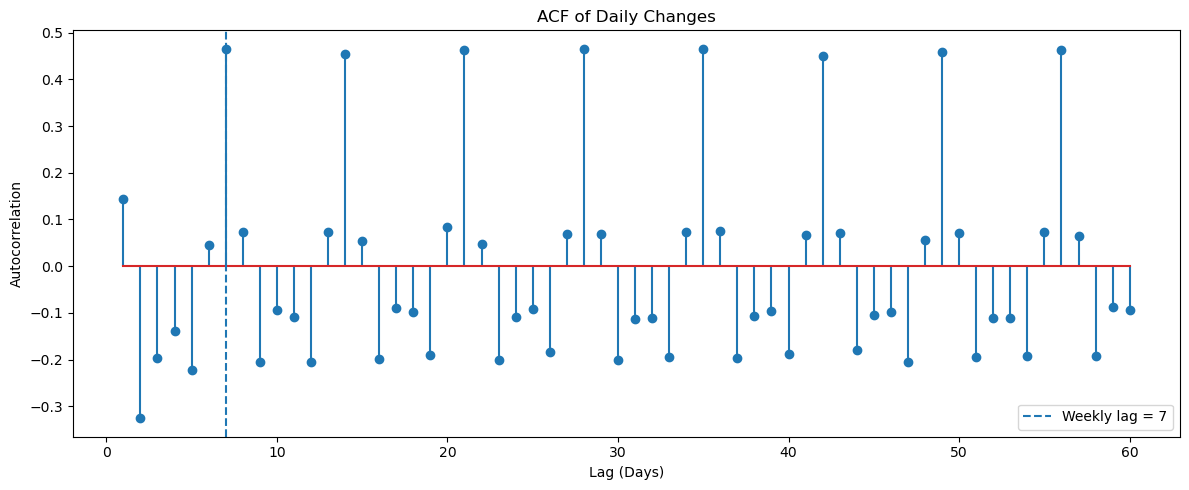

In [67]:
plt.figure(figsize=(12, 5))

plt.stem(
    range(1, 61),
    acf_changes[1:]
)

plt.axvline(
    7,
    linestyle="--",
    label="Weekly lag = 7"
)

plt.title(
    "ACF of Daily Changes"
)

plt.xlabel("Lag (Days)")
plt.ylabel("Autocorrelation")

plt.legend()

plt.tight_layout()
plt.show()

## Seasonal Differencing

The seasonal differencing order `D` is determined by applying the ADF test to the seasonally differenced training series.

Seasonal differencing is calculated using a seasonal lag of 7 observations because the modeling frequency is daily and the identified seasonal cycle is weekly.

In [68]:
# ============================================================
# DETERMINE SEASONAL DIFFERENCING D
# ============================================================

seasonal_diff = (
    train_daily
    .diff(s)
    .dropna()
)

p_seasonal_diff = run_adf(
    seasonal_diff,
    "Seasonally Differenced Training Series"
)

if p_seasonal_diff <= 0.05:
    D = 1
else:
    D = 0

print(
    "\nSelected seasonal differencing order:"
)

print(
    "D =", D
)


ADF Test: Seasonally Differenced Training Series
---------------------------------------------
ADF Statistic : -13.6546
p-value       : 0.0000
Lags Used     : 33
Observations  : 5556
Result: The series is stationary.

Selected seasonal differencing order:
D = 1


## SARIMA Hyperparameter Tuning

The SARIMA parameters are selected through systematic hyperparameter tuning using AIC.

The regular AR and MA orders are searched over:

p = 0, 1, 2
q = 0, 1, 2

The seasonal AR and MA orders are searched over:

P = 0, 1
Q = 0, 1

The regular differencing order `d`, seasonal differencing order `D`, and seasonal period `s` are determined before tuning.

To reduce computational cost while retaining recent seasonal behavior, the most recent three years of the training data are used for SARIMA hyperparameter tuning.

After selecting the best parameters, the final SARIMA model is fitted using the complete training dataset.

In [69]:
# ============================================================
# SARIMA HYPERPARAMETER TUNING
# ============================================================

# Use the most recent 3 years of training data
# for hyperparameter tuning.

tune_data = train_daily.copy()

print("SARIMA tuning data:")
print("Observations:", len(tune_data))
print("Start:", tune_data.index.min())
print("End:", tune_data.index.max())

p_values = range(0, 3)
q_values = range(0, 3)

P_values = range(0, 2)
Q_values = range(0, 2)

sarima_results = []

start_time = time.time()

for p, q, P, Q in itertools.product(
    p_values,
    q_values,
    P_values,
    Q_values
):

    order = (
        p,
        d,
        q
    )

    seasonal_order = (
        P,
        D,
        Q,
        s
    )

    try:

        model = SARIMAX(
            tune_data,
            order=order,
            seasonal_order=seasonal_order,
            enforce_stationarity=False,
            enforce_invertibility=False
        )

        fitted_model = model.fit(
            disp=False
        )

        sarima_results.append(
            {
                "p": p,
                "d": d,
                "q": q,
                "P": P,
                "D": D,
                "Q": Q,
                "s": s,
                "order": order,
                "seasonal_order": seasonal_order,
                "AIC": fitted_model.aic
            }
        )

    except Exception as e:

        print(
            f"SARIMA{order} x "
            f"{seasonal_order} failed: {e}"
        )


sarima_table = (
    pd.DataFrame(sarima_results)
    .sort_values("AIC")
    .reset_index(drop=True)
)

elapsed_time = (
    time.time() - start_time
) / 60

print(
    f"SARIMA tuning completed in "
    f"{elapsed_time:.2f} minutes."
)

print(
    "\nSARIMA hyperparameter results:"
)

display(
    sarima_table
)

SARIMA tuning data:
Observations: 5597
Start: 2002-04-08 00:00:00
End: 2017-08-03 00:00:00
SARIMA tuning completed in 4.02 minutes.

SARIMA hyperparameter results:


,p,d,q,P,D,Q,s,order,seasonal_order,AIC
0,2,0,2,0,1,1,7,"(2, 0, 2)","(0, 1, 1, 7)",78460.376551
1,2,0,2,1,1,1,7,"(2, 0, 2)","(1, 1, 1, 7)",78614.204512
2,1,0,2,1,1,1,7,"(1, 0, 2)","(1, 1, 1, 7)",78651.565009
3,1,0,2,0,1,1,7,"(1, 0, 2)","(0, 1, 1, 7)",78656.408923
4,2,0,1,1,1,1,7,"(2, 0, 1)","(1, 1, 1, 7)",78700.432371
5,2,0,1,0,1,1,7,"(2, 0, 1)","(0, 1, 1, 7)",78715.717834
6,1,0,1,1,1,1,7,"(1, 0, 1)","(1, 1, 1, 7)",78721.067243
7,1,0,1,0,1,1,7,"(1, 0, 1)","(0, 1, 1, 7)",78742.860737
8,2,0,0,1,1,1,7,"(2, 0, 0)","(1, 1, 1, 7)",78842.332884
9,2,0,0,0,1,1,7,"(2, 0, 0)","(0, 1, 1, 7)",78883.375165


### SELECT BEST SARIMA MODEL

In [70]:
best_sarima_order = (
    sarima_table.loc[0, "order"]
)

best_sarima_seasonal = (
    sarima_table.loc[0, "seasonal_order"]
)

best_sarima_aic = (
    sarima_table.loc[0, "AIC"]
)

print(
    "Best SARIMA order:"
)

print(
    best_sarima_order
)

print(
    "\nBest seasonal order:"
)

print(
    best_sarima_seasonal
)

print(
    "\nBest SARIMA AIC:"
)

print(
    best_sarima_aic
)

Best SARIMA order:
(2, 0, 2)

Best seasonal order:
(0, 1, 1, 7)

Best SARIMA AIC:
78460.37655065017


### TOP SARIMA MODELS

In [71]:
print(
    "Top 10 SARIMA models according to AIC:"
)

display(
    sarima_table.head(10)
)

Top 10 SARIMA models according to AIC:


,p,d,q,P,D,Q,s,order,seasonal_order,AIC
0,2,0,2,0,1,1,7,"(2, 0, 2)","(0, 1, 1, 7)",78460.376551
1,2,0,2,1,1,1,7,"(2, 0, 2)","(1, 1, 1, 7)",78614.204512
2,1,0,2,1,1,1,7,"(1, 0, 2)","(1, 1, 1, 7)",78651.565009
3,1,0,2,0,1,1,7,"(1, 0, 2)","(0, 1, 1, 7)",78656.408923
4,2,0,1,1,1,1,7,"(2, 0, 1)","(1, 1, 1, 7)",78700.432371
5,2,0,1,0,1,1,7,"(2, 0, 1)","(0, 1, 1, 7)",78715.717834
6,1,0,1,1,1,1,7,"(1, 0, 1)","(1, 1, 1, 7)",78721.067243
7,1,0,1,0,1,1,7,"(1, 0, 1)","(0, 1, 1, 7)",78742.860737
8,2,0,0,1,1,1,7,"(2, 0, 0)","(1, 1, 1, 7)",78842.332884
9,2,0,0,0,1,1,7,"(2, 0, 0)","(0, 1, 1, 7)",78883.375165


## FINAL SARIMA MODEL


In [72]:
sarima_fit = SARIMAX(
    train_daily,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=False
)

print(
    "Final SARIMA model fitted successfully."
)

print(
    "\nSelected SARIMA order:"
)

print(
    best_sarima_order
)

print(
    "\nSelected seasonal order:"
)

print(
    best_sarima_seasonal
)

print(
    "\nFinal SARIMA AIC:"
)

print(
    sarima_fit.aic
)

Final SARIMA model fitted successfully.

Selected SARIMA order:
(2, 0, 2)

Selected seasonal order:
(0, 1, 1, 7)

Final SARIMA AIC:
78460.37655065017


##  SARIMA TEST-PERIOD FORECAST

In [73]:
sarima_test_result = (
    sarima_fit.get_forecast(
        steps=len(test_daily)
    )
)

sarima_test_mean = (
    sarima_test_result.predicted_mean
)

sarima_test_ci = (
    sarima_test_result.conf_int()
)

sarima_test_forecast_df = pd.DataFrame(
    {
        "Actual": test_daily.values,
        "Forecast": sarima_test_mean.values,
        "Lower_CI": sarima_test_ci.iloc[:, 0].values,
        "Upper_CI": sarima_test_ci.iloc[:, 1].values
    },
    index=test_daily.index
)

sarima_test_forecast_df.index.name = "Date"

display(
    sarima_test_forecast_df.head(10)
)

,Actual,Forecast,Lower_CI,Upper_CI
Date,,,,
2017-08-04,6108.875000,6035.347473,5504.216679,6566.478267
2017-08-05,4997.000000,5588.868063,4816.070556,6361.665570
2017-08-06,4653.291667,5415.125995,4549.419170,6280.832821
2017-08-07,5245.791667,5903.672505,4987.606478,6819.738532
2017-08-08,5461.625000,5976.828386,5027.148288,6926.508485
2017-08-09,5462.750000,5960.421249,4984.972933,6935.869564
2017-08-10,5432.083333,5954.652304,4957.668618,6951.635989
2017-08-11,5647.041667,5877.406437,4860.866326,6893.946549
2017-08-12,5450.041667,5487.805666,4453.519702,6522.091631


###  SARIMA TEST FORECAST VISUALIZATION

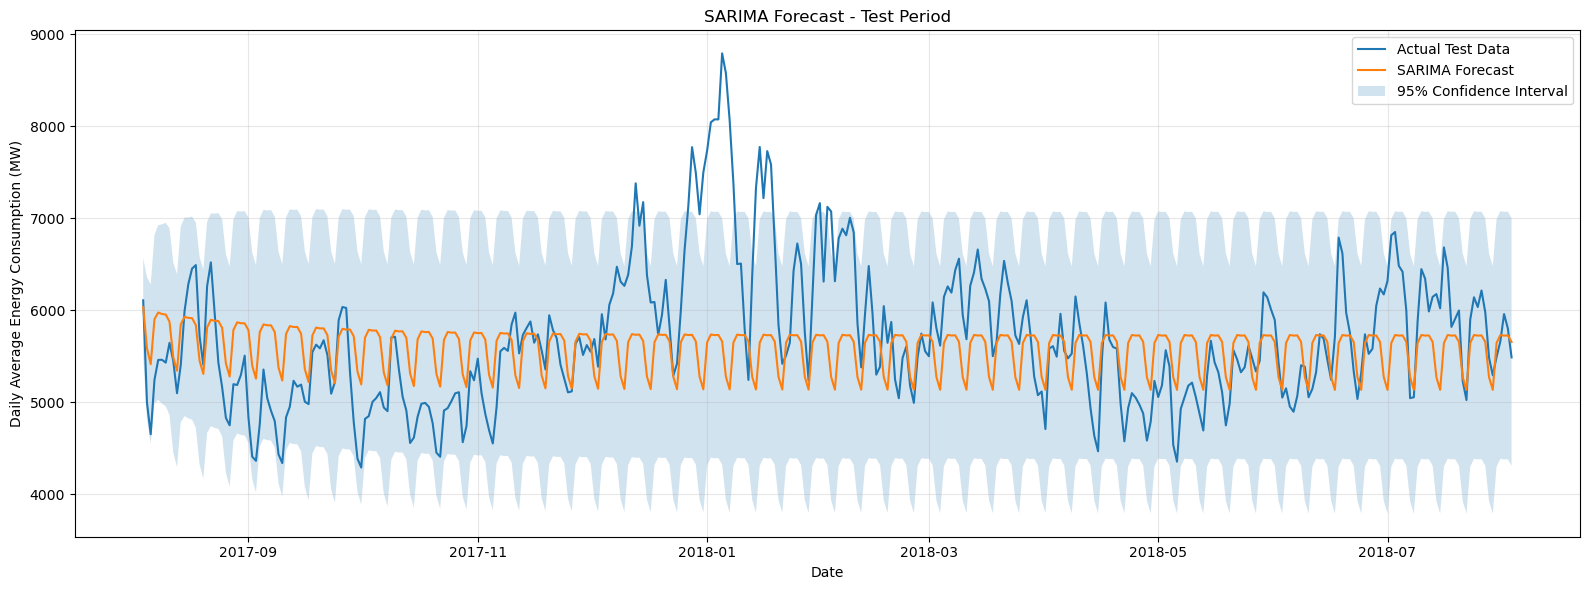

In [74]:

plt.figure(figsize=(16, 6))

plt.plot(
    test_daily.index,
    test_daily.values,
    label="Actual Test Data"
)

plt.plot(
    sarima_test_forecast_df.index,
    sarima_test_forecast_df["Forecast"],
    label="SARIMA Forecast"
)

plt.fill_between(
    sarima_test_forecast_df.index,
    sarima_test_forecast_df["Lower_CI"],
    sarima_test_forecast_df["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA Forecast - Test Period"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

##  ARIMA - NEXT 30 DAYS FORECAST

In [75]:
arima_full_fit = ARIMA(
    daily,
    order=best_arima_order
).fit()

arima_future_result = (
    arima_full_fit.get_forecast(
        steps=30
    )
)

arima_future_mean = (
    arima_future_result.predicted_mean
)

arima_future_ci = (
    arima_future_result.conf_int()
)

future_dates = pd.date_range(
    start=daily.index.max()
    + pd.Timedelta(days=1),
    periods=30,
    freq="D"
)

arima_30_day_forecast = pd.DataFrame(
    {
        "Forecast": arima_future_mean.values,
        "Lower_CI": arima_future_ci.iloc[:, 0].values,
        "Upper_CI": arima_future_ci.iloc[:, 1].values
    },
    index=future_dates
)

arima_30_day_forecast.index.name = "Date"

display(
    arima_30_day_forecast
)

,Forecast,Lower_CI,Upper_CI
Date,,,
2018-08-04,5463.667971,4781.165968,6146.169975
2018-08-05,5554.684887,4562.110485,6547.259289
2018-08-06,5621.002662,4550.322377,6691.682946
2018-08-07,5647.369048,4558.139549,6736.598547
2018-08-08,5645.249170,4547.807046,6742.691293
2018-08-09,5632.070366,4524.416252,6739.724479
2018-08-10,5619.975263,4496.155517,6743.795009
2018-08-11,5613.515773,4468.569636,6758.461911
2018-08-12,5612.075306,4444.720715,6779.429897


## SARIMA - NEXT 30 DAYS FORECAST

In [76]:
sarima_full_fit = SARIMAX(
    daily,
    order=best_sarima_order,
    seasonal_order=best_sarima_seasonal,
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(
    disp=False
)

sarima_future_result = (
    sarima_full_fit.get_forecast(
        steps=30
    )
)

sarima_future_mean = (
    sarima_future_result.predicted_mean
)

sarima_future_ci = (
    sarima_future_result.conf_int()
)

sarima_30_day_forecast = pd.DataFrame(
    {
        "Forecast": sarima_future_mean.values,
        "Lower_CI": sarima_future_ci.iloc[:, 0].values,
        "Upper_CI": sarima_future_ci.iloc[:, 1].values
    },
    index=future_dates
)

sarima_30_day_forecast.index.name = "Date"

display(
    sarima_30_day_forecast
)

,Forecast,Lower_CI,Upper_CI
Date,,,
2018-08-04,5146.344881,4441.414791,5851.274970
2018-08-05,5093.664913,4050.086670,6137.243156
2018-08-06,5637.798237,4460.354576,6815.241899
2018-08-07,5758.401378,4509.527655,7007.275102
2018-08-08,5766.680491,4472.040368,7061.320614
2018-08-09,5760.085826,4431.925042,7088.246611
2018-08-10,5692.691455,4337.549044,7047.833866
2018-08-11,5329.351531,3950.287235,6708.415828
2018-08-12,5195.722117,3795.228790,6596.215444


## ARIMA - NEXT 30 DAYS VISUALIZATION

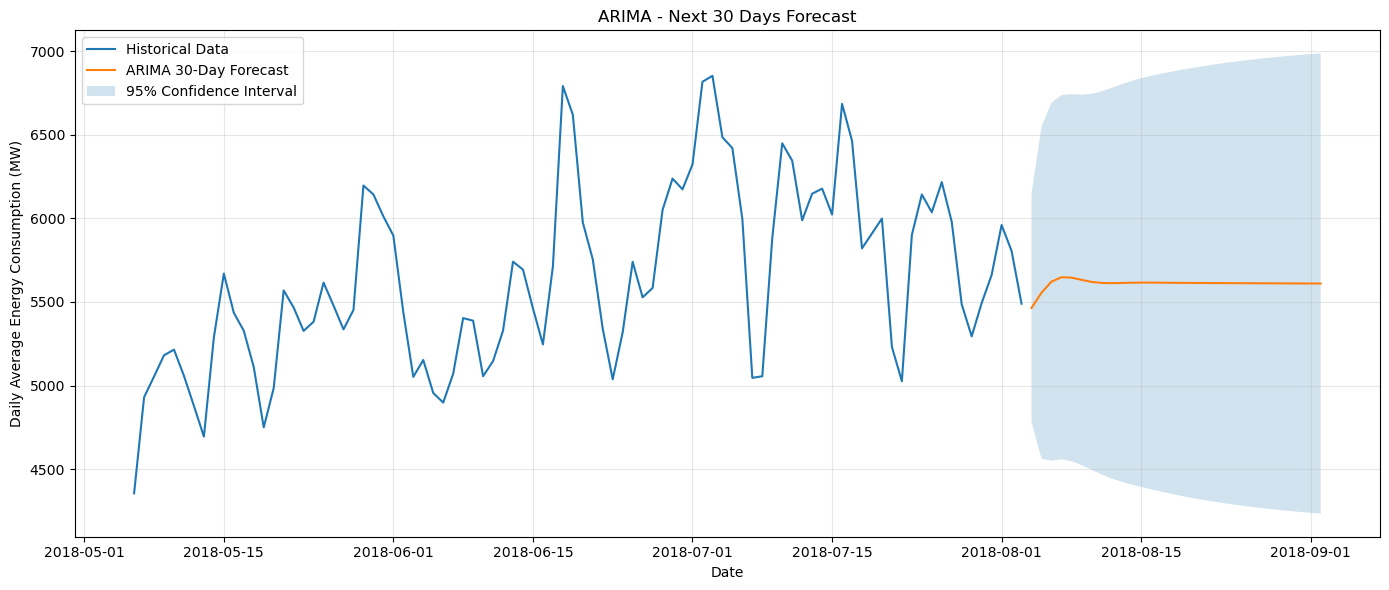

In [77]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily.iloc[-90:].index,
    daily.iloc[-90:].values,
    label="Historical Data"
)

plt.plot(
    arima_30_day_forecast.index,
    arima_30_day_forecast["Forecast"],
    label="ARIMA 30-Day Forecast"
)

plt.fill_between(
    arima_30_day_forecast.index,
    arima_30_day_forecast["Lower_CI"],
    arima_30_day_forecast["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "ARIMA - Next 30 Days Forecast"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## SARIMA - NEXT 30 DAYS VISUALIZATION

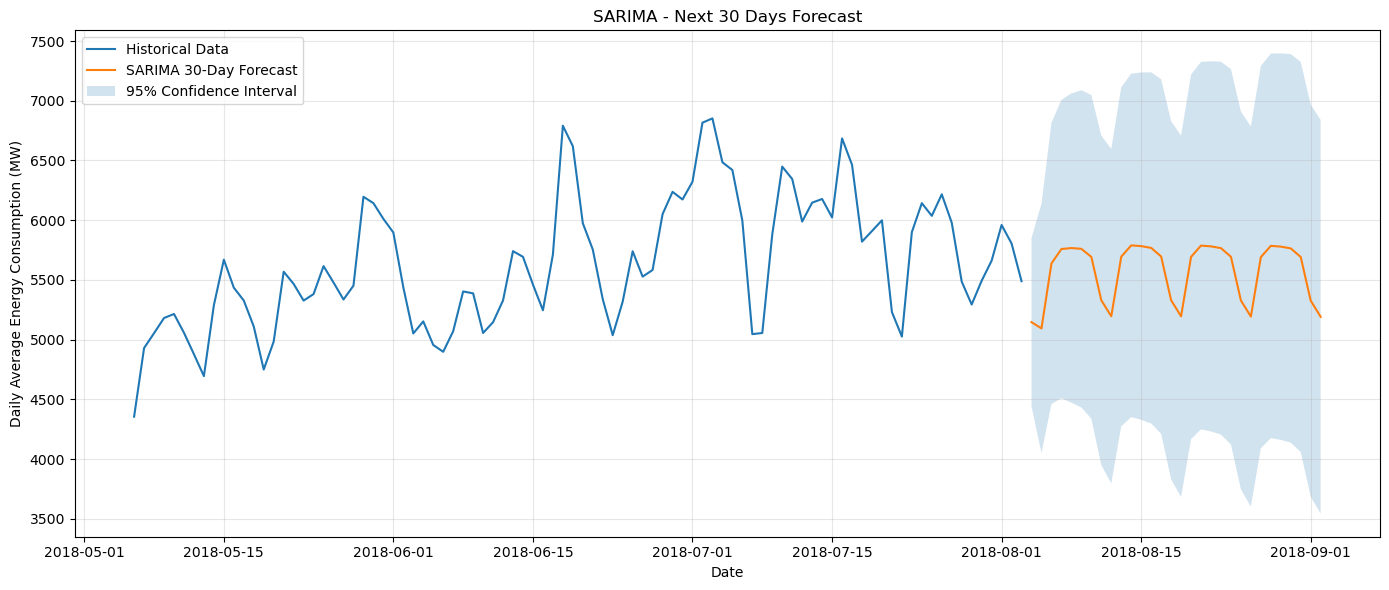

In [78]:
plt.figure(figsize=(14, 6))

plt.plot(
    daily.iloc[-90:].index,
    daily.iloc[-90:].values,
    label="Historical Data"
)

plt.plot(
    sarima_30_day_forecast.index,
    sarima_30_day_forecast["Forecast"],
    label="SARIMA 30-Day Forecast"
)

plt.fill_between(
    sarima_30_day_forecast.index,
    sarima_30_day_forecast["Lower_CI"],
    sarima_30_day_forecast["Upper_CI"],
    alpha=0.2,
    label="95% Confidence Interval"
)

plt.title(
    "SARIMA - Next 30 Days Forecast"
)

plt.xlabel("Date")
plt.ylabel(
    "Daily Average Energy Consumption (MW)"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [79]:
# ============================================================
# SAVE FORECAST RESULTS
# ============================================================

arima_test_forecast_df.to_csv(
    "arima_forecast_test_period.csv"
)

sarima_test_forecast_df.to_csv(
    "sarima_forecast_test_period.csv"
)

arima_30_day_forecast.to_csv(
    "arima_forecast_next_30_days.csv"
)

sarima_30_day_forecast.to_csv(
    "sarima_forecast_next_30_days.csv"
)

print(
    "All forecast files saved successfully."
)

print("\nFiles created:")

print(
    "1. arima_forecast_test_period.csv"
)

print(
    "2. sarima_forecast_test_period.csv"
)

print(
    "3. arima_forecast_next_30_days.csv"
)

print(
    "4. sarima_forecast_next_30_days.csv"
)

All forecast files saved successfully.

Files created:
1. arima_forecast_test_period.csv
2. sarima_forecast_test_period.csv
3. arima_forecast_next_30_days.csv
4. sarima_forecast_next_30_days.csv


## FINAL ARIMA / SARIMA MODELING SUMMARY

In [80]:
print("=" * 65)
print("ARIMA / SARIMA MODELING SUMMARY")
print("=" * 65)

print("\nModeling Dataset:")
print("EDA-prepared daily average PJM energy consumption")

print("\nModeling Frequency:")
print("Daily")

print("\nTotal Observations:")
print(len(daily))

print("\nTraining Observations:")
print(len(train_daily))

print("\nTesting Observations:")
print(len(test_daily))

print("\nTraining Period:")
print(
    train_daily.index.min(),
    "to",
    train_daily.index.max()
)

print("\nTesting Period:")
print(
    test_daily.index.min(),
    "to",
    test_daily.index.max()
)

print("\nSelected ARIMA Order:")
print(best_arima_order)

print("\nSelected SARIMA Order:")
print(best_sarima_order)

print("\nSelected SARIMA Seasonal Order:")
print(best_sarima_seasonal)

print("\nSeasonal Period:")
print(f"{s} days = 1 week")

print("\nForecast Horizon:")
print("30 days")

print("\nFinal Evaluation Metrics:")
print(
    "Not calculated in this modeling section."
)

print(
    "Reserved for the model evaluation/comparison stage."
)

print("\nModel building completed successfully.")

ARIMA / SARIMA MODELING SUMMARY

Modeling Dataset:
EDA-prepared daily average PJM energy consumption

Modeling Frequency:
Daily

Total Observations:
5962

Training Observations:
5597

Testing Observations:
365

Training Period:
2002-04-08 00:00:00 to 2017-08-03 00:00:00

Testing Period:
2017-08-04 00:00:00 to 2018-08-03 00:00:00

Selected ARIMA Order:
(3, 0, 3)

Selected SARIMA Order:
(2, 0, 2)

Selected SARIMA Seasonal Order:
(0, 1, 1, 7)

Seasonal Period:
7 days = 1 week

Forecast Horizon:
30 days

Final Evaluation Metrics:
Not calculated in this modeling section.
Reserved for the model evaluation/comparison stage.

Model building completed successfully.


# ARIMA/SARIMA Modeling Conclusion

The ARIMA and SARIMA models were developed using the daily-average PJM energy consumption series prepared during the EDA stage.

A chronological train-test split was performed, with the final 365 daily observations reserved as the test period in accordance with the project requirement.

For ARIMA, stationarity was assessed using the Augmented Dickey-Fuller test and the differencing order `d` was selected accordingly. The autoregressive and moving-average parameters were tuned systematically using AIC, and the best-performing parameter combination according to AIC was selected for the final ARIMA model.

For SARIMA, the weekly seasonal pattern identified during EDA was incorporated into the model. Since the modeling data is daily, the seasonal period was set to 7 observations, representing one week. Seasonal differencing was assessed using the ADF test on the seasonally differenced series. The regular and seasonal AR/MA parameters were then tuned using a systematic grid search based on AIC.

The final ARIMA and SARIMA models were fitted using the selected hyperparameters and used to generate forecasts for the held-out test period.

Both models were subsequently fitted using the available daily data to generate forecasts for the next 30 days.

The generated forecast outputs are saved as CSV files for the model evaluation and comparison stage.


# LSTM MODEL - IMPORTS

In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("LSTM libraries imported successfully.")

LSTM libraries imported successfully.


### LSTM DATA PREPARATION

In [82]:
lstm_df = df[["Datetime", "PJMW_MW"]].copy()

lstm_df["Datetime"] = pd.to_datetime(lstm_df["Datetime"])
lstm_df = lstm_df.sort_values("Datetime").reset_index(drop=True)

# Remove rows where target is missing
lstm_df = lstm_df.dropna(subset=["PJMW_MW"])

print("LSTM dataset shape:", lstm_df.shape)
print("Missing values:", lstm_df["PJMW_MW"].isna().sum())

display(lstm_df.head())

LSTM dataset shape: (143034, 2)
Missing values: 0


,Datetime,PJMW_MW
0,2002-04-08 02:00:00,4532
1,2002-04-08 03:00:00,4481
2,2002-04-08 04:00:00,4527
3,2002-04-08 05:00:00,4640
4,2002-04-08 06:00:00,4940



### LSTM CHRONOLOGICAL TRAIN-TEST SPLIT



In [83]:

test_size_lstm = 8760       # approximately one year of hourly data

train_lstm = lstm_df.iloc[:-test_size_lstm].copy()
test_lstm = lstm_df.iloc[-test_size_lstm:].copy()

print("Training observations:", len(train_lstm))
print("Testing observations :", len(test_lstm))

print("\nTraining period:")
print(train_lstm["Datetime"].min(), "to", train_lstm["Datetime"].max())

print("\nTesting period:")
print(test_lstm["Datetime"].min(), "to", test_lstm["Datetime"].max())

Training observations: 134274
Testing observations : 8760

Training period:
2002-04-08 02:00:00 to 2017-08-02 23:00:00

Testing period:
2017-08-03 00:00:00 to 2018-08-03 00:00:00


### LSTM FEATURE SCALING

In [84]:
lstm_scaler = MinMaxScaler(feature_range=(0, 1))

train_values = train_lstm[["PJMW_MW"]].values
test_values = test_lstm[["PJMW_MW"]].values

train_scaled = lstm_scaler.fit_transform(train_values)
test_scaled = lstm_scaler.transform(test_values)

print("Training scaled shape:", train_scaled.shape)
print("Testing scaled shape :", test_scaled.shape)

Training scaled shape: (134274, 1)
Testing scaled shape : (8760, 1)


### CREATE LSTM SEQUENCES

In [85]:

time_steps = 24

def create_sequences(data, time_steps):
    X = []
    y = []

    for i in range(time_steps, len(data)):
        X.append(data[i-time_steps:i, 0])
        y.append(data[i, 0])

    return np.array(X), np.array(y)


X_train_lstm, y_train_lstm = create_sequences(
    train_scaled,
    time_steps
)

# Test sequences need the last 24 training observations
# so that the first test prediction has previous-hour information.
combined_test = np.vstack([
    train_scaled[-time_steps:],
    test_scaled
])

X_test_lstm, y_test_lstm = create_sequences(
    combined_test,
    time_steps
)

print("X_train shape:", X_train_lstm.shape)
print("y_train shape:", y_train_lstm.shape)

print("X_test shape :", X_test_lstm.shape)
print("y_test shape :", y_test_lstm.shape)

X_train shape: (134250, 24)
y_train shape: (134250,)
X_test shape : (8760, 24)
y_test shape : (8760,)


### RESHAPE DATA FOR LSTM

In [108]:

X_train_lstm = X_train_lstm.reshape(
    X_train_lstm.shape[0],
    X_train_lstm.shape[1],
    1
)

X_test_lstm = X_test_lstm.reshape(
    X_test_lstm.shape[0],
    X_test_lstm.shape[1],
    1
)

print("Final X_train shape:", X_train_lstm.shape)
print("Final X_test shape :", X_test_lstm.shape)

Final X_train shape: (134250, 24, 1)
Final X_test shape : (8760, 24, 1)


### LSTM MODEL BUILDING

In [109]:
lstm_model = Sequential([
    
    LSTM(
        64,
        return_sequences=True,
        input_shape=(time_steps, 1)
    ),
    
    Dropout(0.2),
    
    LSTM(32),
    
    Dropout(0.2),
    
    Dense(16, activation="relu"),
    
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse"
)

lstm_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_2 (LSTM)                        │ (None, 24, 64)              │          16,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 24, 64)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_3 (LSTM)                        │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 29,857 (116.63 KB)

 Trainable params: 29,857 (116.63 KB)

 Non-trainable params: 0 (0.00 B)

### LSTM MODEL TRAINING

In [110]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

history = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,
    epochs=30,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stopping],
    verbose=1,
    shuffle=False
)

print("LSTM model training completed.")

Epoch 1/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 34s 16ms/step - loss: 0.0055 - val_loss: 8.1441e-04
Epoch 2/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 7.6320e-04 - val_loss: 3.0535e-04
Epoch 3/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 4.7272e-04 - val_loss: 1.8208e-04
Epoch 4/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 3.5789e-04 - val_loss: 2.2979e-04
Epoch 5/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 3.0434e-04 - val_loss: 2.8189e-04
Epoch 6/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 2.6709e-04 - val_loss: 3.6439e-04
Epoch 7/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 2.4652e-04 - val_loss: 4.5386e-04
Epoch 8/30
1888/1888 ━━━━━━━━━━━━━━━━━━━━ 31s 16ms/step - loss: 2.2672e-04 - val_loss: 5.6064e-04
LSTM model training completed.


### LSTM TRAINING HISTORY


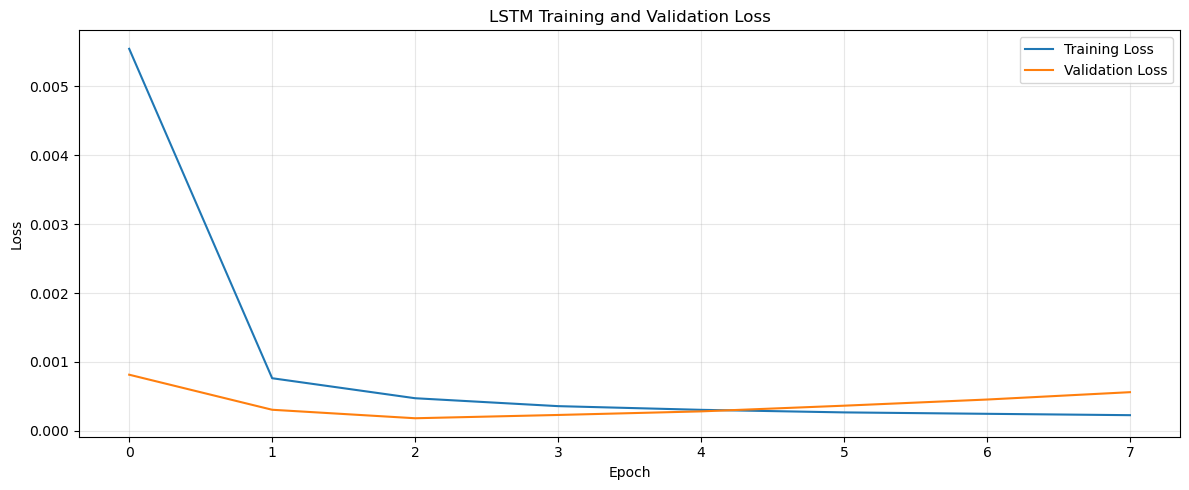

In [111]:
plt.figure(figsize=(12, 5))

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.title("LSTM Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### LSTM TEST PREDICTION

In [112]:
lstm_pred_scaled = lstm_model.predict(
    X_test_lstm,
    verbose=0
)

# Convert predictions back to original MW scale
lstm_pred = lstm_scaler.inverse_transform(
    lstm_pred_scaled
).flatten()

actual_lstm = lstm_scaler.inverse_transform(
    y_test_lstm.reshape(-1, 1)
).flatten()

lstm_forecast_df = pd.DataFrame({
    "Datetime": test_lstm["Datetime"].values,
    "Actual": actual_lstm,
    "Forecast": lstm_pred
})

lstm_forecast_df.set_index(
    "Datetime",
    inplace=True
)

display(lstm_forecast_df.head())

,Actual,Forecast
Datetime,,
2017-08-03 00:00:00,5591.0,5879.576660
2017-08-03 01:00:00,5170.0,5178.542969
2017-08-03 02:00:00,4948.0,4868.264648
2017-08-03 03:00:00,4700.0,4797.091797
2017-08-03 04:00:00,4606.0,4653.199707


### LSTM FORECAST VISUALIZATION

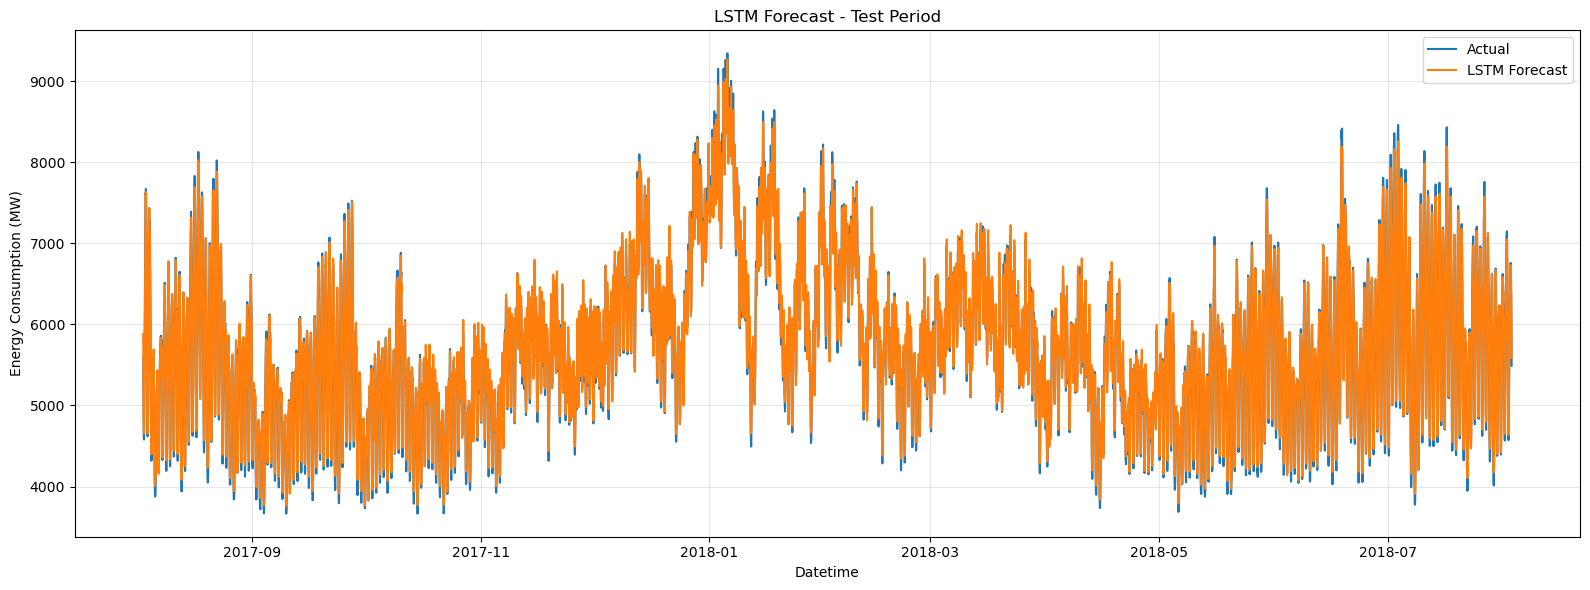

In [113]:
plt.figure(figsize=(16, 6))

plt.plot(
    lstm_forecast_df.index,
    lstm_forecast_df["Actual"],
    label="Actual"
)

plt.plot(
    lstm_forecast_df.index,
    lstm_forecast_df["Forecast"],
    label="LSTM Forecast"
)

plt.title("LSTM Forecast - Test Period")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# XGBOOST - IMPORTS

In [114]:
from xgboost import XGBRegressor

print("XGBoost imported successfully.")

XGBoost imported successfully.


### XGBOOST FEATURE ENGINEERING

In [115]:
xgb_df = df[["Datetime", "PJMW_MW"]].copy()

xgb_df["Datetime"] = pd.to_datetime(xgb_df["Datetime"])
xgb_df = xgb_df.sort_values("Datetime").reset_index(drop=True)

# Time features
xgb_df["Hour"] = xgb_df["Datetime"].dt.hour
xgb_df["DayOfWeek"] = xgb_df["Datetime"].dt.dayofweek
xgb_df["Month"] = xgb_df["Datetime"].dt.month
xgb_df["DayOfYear"] = xgb_df["Datetime"].dt.dayofyear
xgb_df["Weekend"] = (
    xgb_df["DayOfWeek"] >= 5
).astype(int)

# Lag features
xgb_df["Lag_1"] = xgb_df["PJMW_MW"].shift(1)
xgb_df["Lag_24"] = xgb_df["PJMW_MW"].shift(24)
xgb_df["Lag_48"] = xgb_df["PJMW_MW"].shift(48)
xgb_df["Lag_168"] = xgb_df["PJMW_MW"].shift(168)

# Rolling features
xgb_df["Rolling_Mean_24"] = (
    xgb_df["PJMW_MW"]
    .shift(1)
    .rolling(24)
    .mean()
)

xgb_df["Rolling_Mean_168"] = (
    xgb_df["PJMW_MW"]
    .shift(1)
    .rolling(168)
    .mean()
)

# Remove rows created by lag/rolling operations
xgb_df = xgb_df.dropna().reset_index(drop=True)

print("XGBoost dataset shape:", xgb_df.shape)

display(xgb_df.head())

XGBoost dataset shape: (142866, 13)


,Datetime,PJMW_MW,Hour,DayOfWeek,Month,DayOfYear,Weekend,Lag_1,Lag_24,Lag_48,Lag_168,Rolling_Mean_24,Rolling_Mean_168
0,2002-04-15 02:00:00,4030,2,0,4,105,0,4134.0,3780.0,4106.0,4532.0,4408.208333,4976.559524
1,2002-04-15 03:00:00,3983,3,0,4,105,0,4030.0,3750.0,4015.0,4481.0,4418.625000,4973.571429
2,2002-04-15 04:00:00,3993,4,0,4,105,0,3983.0,3727.0,3934.0,4527.0,4428.333333,4970.607143
3,2002-04-15 05:00:00,4072,5,0,4,105,0,3993.0,3704.0,3928.0,4640.0,4439.416667,4967.428571
4,2002-04-15 06:00:00,4382,6,0,4,105,0,4072.0,3770.0,4080.0,4940.0,4454.750000,4964.047619


### XGBOOST FEATURES AND TARGET

In [116]:
xgb_features = [
    "Hour",
    "DayOfWeek",
    "Month",
    "DayOfYear",
    "Weekend",
    "Lag_1",
    "Lag_24",
    "Lag_48",
    "Lag_168",
    "Rolling_Mean_24",
    "Rolling_Mean_168"
]

X_xgb = xgb_df[xgb_features]
y_xgb = xgb_df["PJMW_MW"]

print("Features:")
print(xgb_features)

print("\nX shape:", X_xgb.shape)
print("y shape:", y_xgb.shape)

Features:
['Hour', 'DayOfWeek', 'Month', 'DayOfYear', 'Weekend', 'Lag_1', 'Lag_24', 'Lag_48', 'Lag_168', 'Rolling_Mean_24', 'Rolling_Mean_168']

X shape: (142866, 11)
y shape: (142866,)


### XGBOOST CHRONOLOGICAL TRAIN-TEST SPLIT

In [117]:
test_size_xgb = 8760

X_train_xgb = X_xgb.iloc[:-test_size_xgb].copy()
X_test_xgb = X_xgb.iloc[-test_size_xgb:].copy()

y_train_xgb = y_xgb.iloc[:-test_size_xgb].copy()
y_test_xgb = y_xgb.iloc[-test_size_xgb:].copy()

print("X_train:", X_train_xgb.shape)
print("X_test :", X_test_xgb.shape)

print("\nTraining period:")
print(
    xgb_df["Datetime"].iloc[:-test_size_xgb].min(),
    "to",
    xgb_df["Datetime"].iloc[:-test_size_xgb].max()
)

print("\nTesting period:")
print(
    xgb_df["Datetime"].iloc[-test_size_xgb:].min(),
    "to",
    xgb_df["Datetime"].iloc[-1]
)

X_train: (134106, 11)
X_test : (8760, 11)

Training period:
2002-04-15 02:00:00 to 2017-08-02 23:00:00

Testing period:
2017-08-03 00:00:00 to 2018-08-03 00:00:00


### XGBOOST MODEL BUILDING

In [118]:
xgb_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    min_child_weight=3,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="reg:squarederror",
    random_state=42,
    n_jobs=-1
)

xgb_model.fit(
    X_train_xgb,
    y_train_xgb
)

print("XGBoost model trained successfully.")

XGBoost model trained successfully.


### XGBOOST TEST PREDICTION

In [119]:
xgb_pred = xgb_model.predict(
    X_test_xgb
)

xgb_forecast_df = pd.DataFrame({
    "Datetime": xgb_df["Datetime"].iloc[-test_size_xgb:].values,
    "Actual": y_test_xgb.values,
    "Forecast": xgb_pred
})

xgb_forecast_df.set_index(
    "Datetime",
    inplace=True
)

display(xgb_forecast_df.head())

,Actual,Forecast
Datetime,,
2017-08-03 00:00:00,5591,5678.286133
2017-08-03 01:00:00,5170,5175.815918
2017-08-03 02:00:00,4948,4892.155273
2017-08-03 03:00:00,4700,4761.738770
2017-08-03 04:00:00,4606,4603.438965


### XGBOOST FORECAST VISUALIZATION

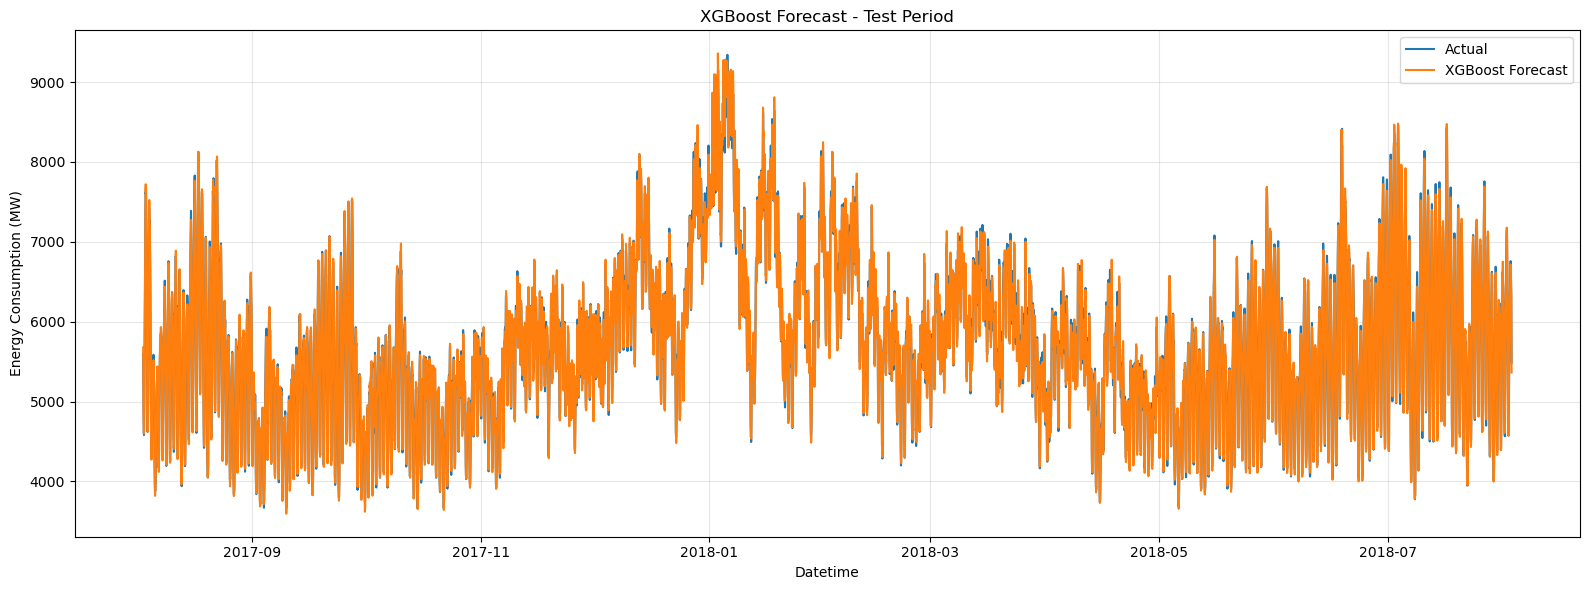

In [120]:
plt.figure(figsize=(16, 6))

plt.plot(
    xgb_forecast_df.index,
    xgb_forecast_df["Actual"],
    label="Actual"
)

plt.plot(
    xgb_forecast_df.index,
    xgb_forecast_df["Forecast"],
    label="XGBoost Forecast"
)

plt.title("XGBoost Forecast - Test Period")
plt.xlabel("Datetime")
plt.ylabel("Energy Consumption (MW)")
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# MODEL EVALUATION

In [99]:
# ============================================================
# MODEL EVALUATION - METRICS FUNCTION
# ============================================================

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np
import pandas as pd

def calculate_metrics(actual, forecast):

    actual = np.asarray(actual)
    forecast = np.asarray(forecast)

    mae = mean_absolute_error(actual, forecast)

    mse = mean_squared_error(actual, forecast)

    rmse = np.sqrt(mse)

    non_zero = actual != 0

    mape = np.mean(
        np.abs(
            (actual[non_zero] - forecast[non_zero])
            / actual[non_zero]
        )
    ) * 100

    r2 = r2_score(actual, forecast)

    return {
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "MAPE (%)": mape,
        "R2": r2
    }

print("Evaluation metrics function created successfully.")

Evaluation metrics function created successfully.


### COMMON DAILY MODEL EVALUATION

In [121]:
# Convert LSTM hourly predictions to daily averages

lstm_daily_eval = lstm_forecast_df.copy()

lstm_daily_eval["Date"] = (
    pd.to_datetime(lstm_daily_eval.index)
    .normalize()
)

lstm_daily_eval = (
    lstm_daily_eval
    .groupby("Date")[["Actual", "Forecast"]]
    .mean()
)


# Convert XGBoost hourly predictions to daily averages

xgb_daily_eval = xgb_forecast_df.copy()

xgb_daily_eval["Date"] = (
    pd.to_datetime(xgb_daily_eval.index)
    .normalize()
)

xgb_daily_eval = (
    xgb_daily_eval
    .groupby("Date")[["Actual", "Forecast"]]
    .mean()
)


# Find common dates for all models

common_dates = (
    test_daily.index
    .intersection(lstm_daily_eval.index)
    .intersection(xgb_daily_eval.index)
)


print("Common daily test observations:", len(common_dates))
print("Start date:", common_dates.min())
print("End date:", common_dates.max())

Common daily test observations: 365
Start date: 2017-08-04 00:00:00
End date: 2018-08-03 00:00:00


### ARIMA AND SARIMA - DAILY EVALUATION

In [122]:
arima_metrics = calculate_metrics(
    test_daily.loc[common_dates].values,
    arima_test_forecast_df.loc[
        common_dates,
        "Forecast"
    ].values
)


sarima_metrics = calculate_metrics(
    test_daily.loc[common_dates].values,
    sarima_test_forecast_df.loc[
        common_dates,
        "Forecast"
    ].values
)


print("ARIMA Evaluation")
print("----------------")

for metric, value in arima_metrics.items():
    print(f"{metric}: {value:.4f}")


print("\nSARIMA Evaluation")
print("-----------------")

for metric, value in sarima_metrics.items():
    print(f"{metric}: {value:.4f}")

ARIMA Evaluation
----------------
MAE: 586.4218
MSE: 607014.7257
RMSE: 779.1115
MAPE (%): 10.0614
R2: -0.0340

SARIMA Evaluation
-----------------
MAE: 566.8079
MSE: 576614.1812
RMSE: 759.3512
MAPE (%): 9.6134
R2: 0.0177


### LSTM - DAILY EVALUATION

In [123]:
lstm_metrics = calculate_metrics(
    lstm_daily_eval.loc[
        common_dates,
        "Actual"
    ].values,

    lstm_daily_eval.loc[
        common_dates,
        "Forecast"
    ].values
)

print("LSTM Evaluation - Daily")
print("------------------------")

for metric, value in lstm_metrics.items():
    print(f"{metric}: {value:.4f}")

LSTM Evaluation - Daily
------------------------
MAE: 43.5465
MSE: 3434.9340
RMSE: 58.6083
MAPE (%): 0.7427
R2: 0.9941


### XGBOOST - DAILY EVALUATION

In [124]:
xgb_metrics = calculate_metrics(
    xgb_daily_eval.loc[
        common_dates,
        "Actual"
    ].values,

    xgb_daily_eval.loc[
        common_dates,
        "Forecast"
    ].values
)

print("XGBoost Evaluation - Daily")
print("--------------------------")

for metric, value in xgb_metrics.items():
    print(f"{metric}: {value:.4f}")

XGBoost Evaluation - Daily
--------------------------
MAE: 21.5201
MSE: 1066.3764
RMSE: 32.6554
MAPE (%): 0.3623
R2: 0.9982


### FINAL MODEL EVALUATION - ALL 4 MODELS

In [125]:
model_evaluation = pd.DataFrame({

    "Model": [
        "ARIMA",
        "SARIMA",
        "LSTM",
        "XGBoost"
    ],

    "MAE": [
        arima_metrics["MAE"],
        sarima_metrics["MAE"],
        lstm_metrics["MAE"],
        xgb_metrics["MAE"]
    ],

    "MSE": [
        arima_metrics["MSE"],
        sarima_metrics["MSE"],
        lstm_metrics["MSE"],
        xgb_metrics["MSE"]
    ],

    "RMSE": [
        arima_metrics["RMSE"],
        sarima_metrics["RMSE"],
        lstm_metrics["RMSE"],
        xgb_metrics["RMSE"]
    ],

    "MAPE (%)": [
        arima_metrics["MAPE (%)"],
        sarima_metrics["MAPE (%)"],
        lstm_metrics["MAPE (%)"],
        xgb_metrics["MAPE (%)"]
    ],

    "R2": [
        arima_metrics["R2"],
        sarima_metrics["R2"],
        lstm_metrics["R2"],
        xgb_metrics["R2"]
    ]
})

print("FINAL MODEL EVALUATION")
print("======================")

display(model_evaluation.round(4))

FINAL MODEL EVALUATION


,Model,MAE,MSE,RMSE,MAPE (%),R2
0,ARIMA,586.4218,607014.7257,779.1115,10.0614,-0.0340
1,SARIMA,566.8079,576614.1812,759.3512,9.6134,0.0177
2,LSTM,43.5465,3434.9340,58.6083,0.7427,0.9941
3,XGBoost,21.5201,1066.3764,32.6554,0.3623,0.9982


### ACTUAL VS PREDICTED - ALL MODELS



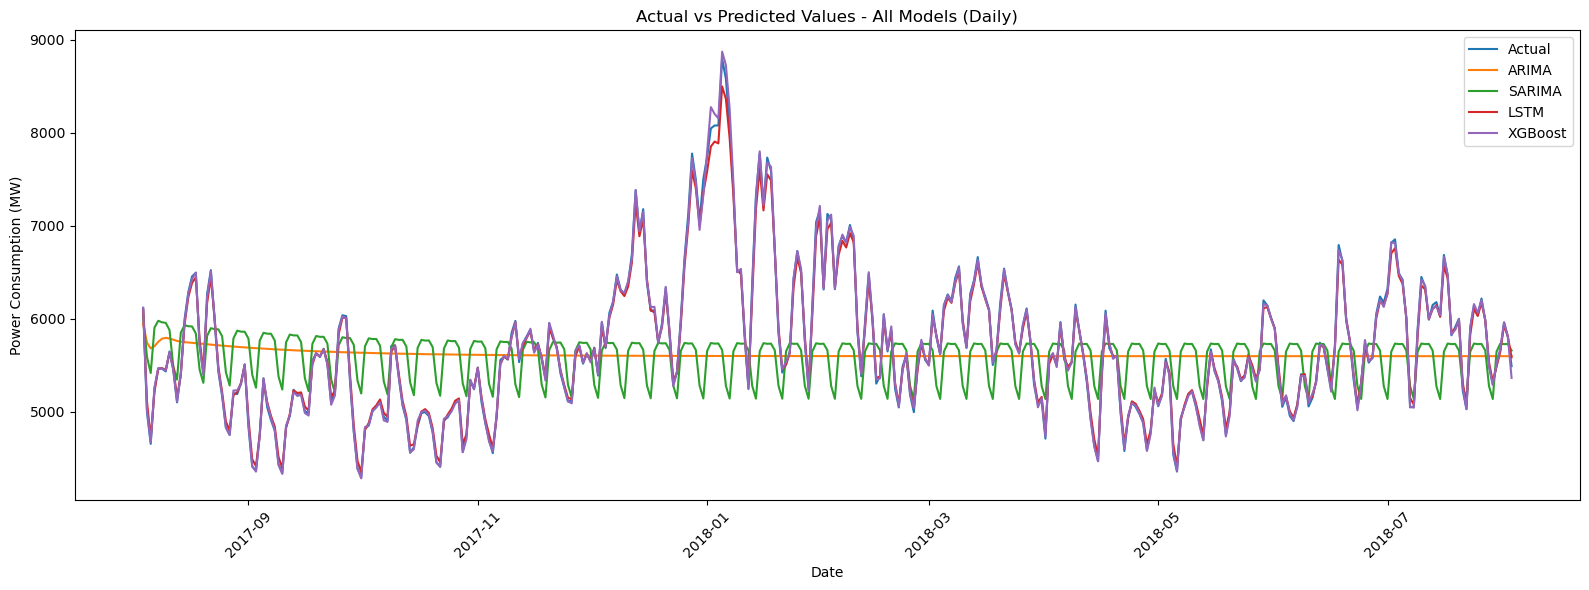

In [126]:
### COMMON DAILY TEST PERIOD
plt.figure(figsize=(16, 6))

# Actual values
plt.plot(
    common_dates,
    test_daily.loc[common_dates].values,
    label="Actual"
)

# ARIMA
plt.plot(
    common_dates,
    arima_test_forecast_df.loc[
        common_dates, "Forecast"
    ].values,
    label="ARIMA"
)

# SARIMA
plt.plot(
    common_dates,
    sarima_test_forecast_df.loc[
        common_dates, "Forecast"
    ].values,
    label="SARIMA"
)

# LSTM - daily
plt.plot(
    common_dates,
    lstm_daily_eval.loc[
        common_dates, "Forecast"
    ].values,
    label="LSTM"
)

# XGBoost - daily
plt.plot(
    common_dates,
    xgb_daily_eval.loc[
        common_dates, "Forecast"
    ].values,
    label="XGBoost"
)

plt.title(
    "Actual vs Predicted Values - All Models (Daily)"
)

plt.xlabel("Date")
plt.ylabel("Power Consumption (MW)")

plt.legend()
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

### MODEL PERFORMANCE COMPARISON


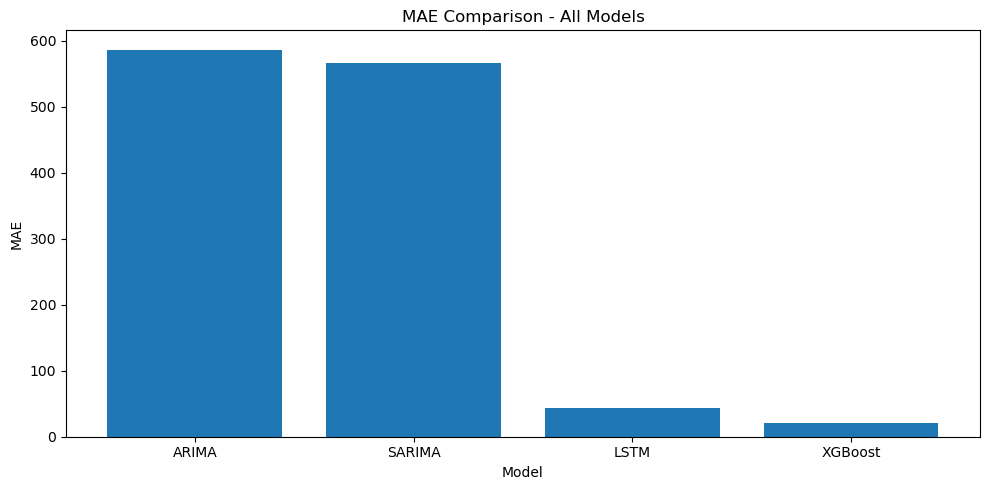

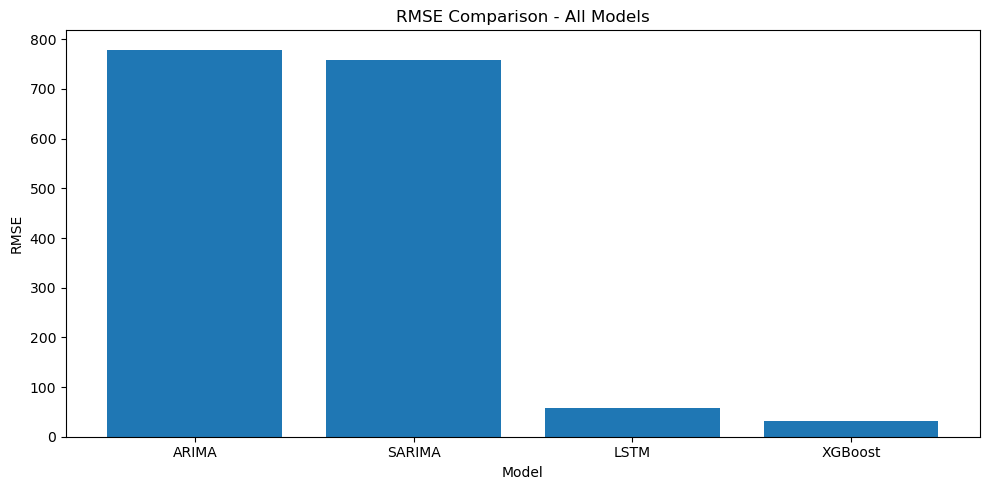

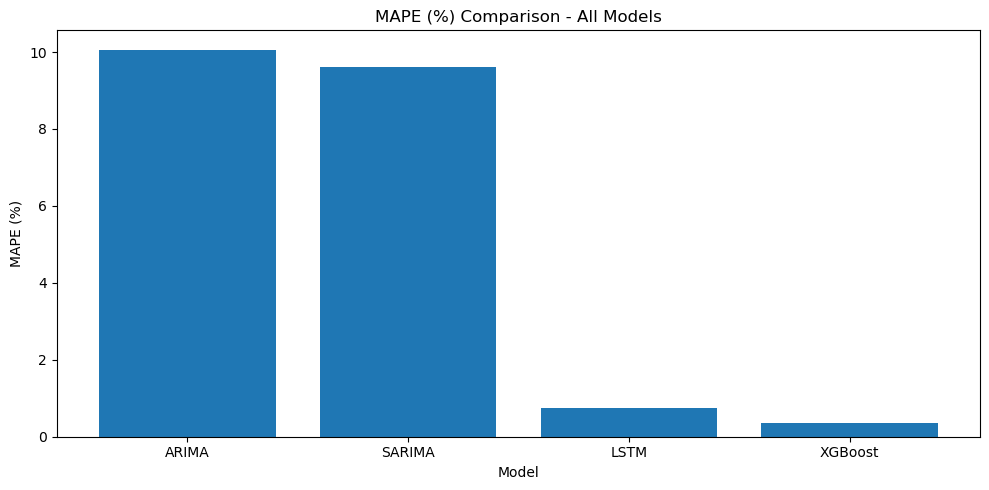

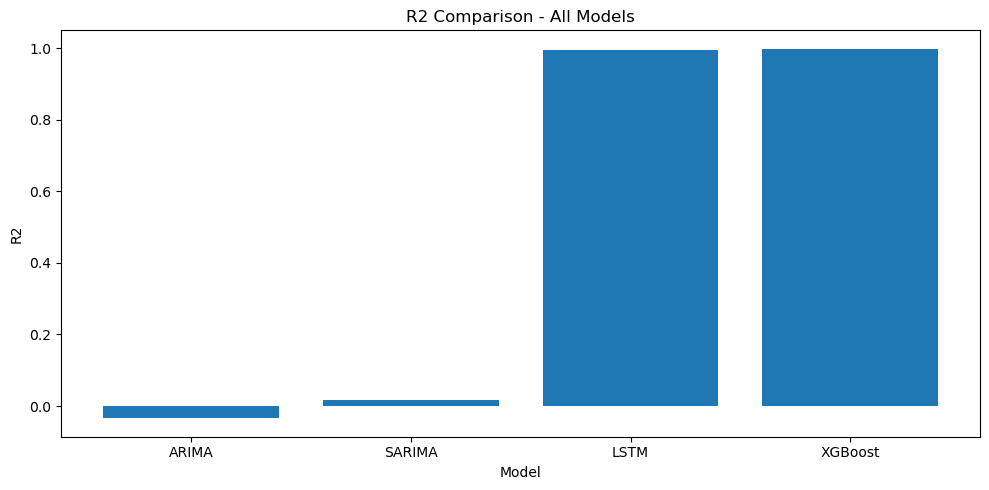

In [127]:
metrics_to_plot = [
    "MAE",
    "RMSE",
    "MAPE (%)",
    "R2"
]

for metric in metrics_to_plot:

    plt.figure(figsize=(10, 5))

    plt.bar(
        model_evaluation["Model"],
        model_evaluation[metric]
    )

    plt.title(
        f"{metric} Comparison - All Models"
    )

    plt.xlabel("Model")
    plt.ylabel(metric)

    plt.xticks(rotation=0)

    plt.tight_layout()
    plt.show()

# Model Selection

After evaluating the ARIMA, SARIMA, LSTM, and XGBoost models, their performance is compared using MAE, MSE, RMSE, MAPE, and R².

MAE, MSE, RMSE, and MAPE measure the prediction error, so lower values indicate better performance. R² measures how well the model explains the variation in the actual data, so a higher value indicates better performance.

The final model is selected based on its overall performance on the test data, considering lower prediction errors and a higher R² score.

### FINAL MODEL EVALUATION AND SELECTION


In [107]:
print("FINAL MODEL PERFORMANCE COMPARISON")
print("=" * 60)

display(model_evaluation.round(4))


# ------------------------------------------------------------
# IDENTIFY BEST MODEL FOR EACH METRIC
# ------------------------------------------------------------

best_mae_model = model_evaluation.loc[
    model_evaluation["MAE"].idxmin(), "Model"
]

best_mse_model = model_evaluation.loc[
    model_evaluation["MSE"].idxmin(), "Model"
]

best_rmse_model = model_evaluation.loc[
    model_evaluation["RMSE"].idxmin(), "Model"
]

best_mape_model = model_evaluation.loc[
    model_evaluation["MAPE (%)"].idxmin(), "Model"
]

best_r2_model = model_evaluation.loc[
    model_evaluation["R2"].idxmax(), "Model"
]


# ------------------------------------------------------------
# DISPLAY BEST MODEL FOR EACH METRIC
# ------------------------------------------------------------

print("\nBEST MODEL FOR EACH METRIC")
print("=" * 60)

print("Lowest MAE   :", best_mae_model)
print("Lowest MSE   :", best_mse_model)
print("Lowest RMSE  :", best_rmse_model)
print("Lowest MAPE  :", best_mape_model)
print("Highest R²   :", best_r2_model)


# ------------------------------------------------------------
# CREATE A RANK-BASED PERFORMANCE SCORE
# Lower average rank indicates better overall performance.
# Lower errors are better, while higher R² is better.
# ------------------------------------------------------------

evaluation_score = model_evaluation.copy()

# Rank error metrics: lower value = better rank
evaluation_score["MAE_Rank"] = (
    evaluation_score["MAE"].rank(ascending=True)
)

evaluation_score["MSE_Rank"] = (
    evaluation_score["MSE"].rank(ascending=True)
)

evaluation_score["RMSE_Rank"] = (
    evaluation_score["RMSE"].rank(ascending=True)
)

evaluation_score["MAPE_Rank"] = (
    evaluation_score["MAPE (%)"].rank(ascending=True)
)

# Rank R²: higher value = better rank
evaluation_score["R2_Rank"] = (
    evaluation_score["R2"].rank(ascending=False)
)


# Average rank across all evaluation metrics
evaluation_score["Average_Rank"] = (
    evaluation_score[
        [
            "MAE_Rank",
            "MSE_Rank",
            "RMSE_Rank",
            "MAPE_Rank",
            "R2_Rank"
        ]
    ].mean(axis=1)
)


# ------------------------------------------------------------
# SELECT MODEL WITH THE BEST OVERALL AVERAGE RANK
# ------------------------------------------------------------

final_model = evaluation_score.loc[
    evaluation_score["Average_Rank"].idxmin(),
    "Model"
]


print("\nFINAL MODEL SELECTED")
print("=" * 60)
print("Selected Model:", final_model)


# ------------------------------------------------------------
# DISPLAY FINAL RANKING
# ------------------------------------------------------------

final_ranking = (
    evaluation_score[
        ["Model", "MAE", "MSE", "RMSE", "MAPE (%)", "R2", "Average_Rank"]
    ]
    .sort_values("Average_Rank")
    .reset_index(drop=True)
)

print("\nFINAL MODEL RANKING")
print("=" * 60)

display(final_ranking.round(4))

FINAL MODEL PERFORMANCE COMPARISON


,Model,MAE,MSE,RMSE,MAPE (%),R2
0,ARIMA,586.4218,607014.7257,779.1115,10.0614,-0.0340
1,SARIMA,566.8079,576614.1812,759.3512,9.6134,0.0177
2,LSTM,240.0151,78188.9391,279.6229,3.9843,0.8668
3,XGBoost,21.5201,1066.3764,32.6554,0.3623,0.9982



BEST MODEL FOR EACH METRIC
Lowest MAE   : XGBoost
Lowest MSE   : XGBoost
Lowest RMSE  : XGBoost
Lowest MAPE  : XGBoost
Highest R²   : XGBoost

FINAL MODEL SELECTED
Selected Model: XGBoost

FINAL MODEL RANKING


,Model,MAE,MSE,RMSE,MAPE (%),R2,Average_Rank
0,XGBoost,21.5201,1066.3764,32.6554,0.3623,0.9982,1.0
1,LSTM,240.0151,78188.9391,279.6229,3.9843,0.8668,2.0
2,SARIMA,566.8079,576614.1812,759.3512,9.6134,0.0177,3.0
3,ARIMA,586.4218,607014.7257,779.1115,10.0614,-0.0340,4.0


### Final Model Selection

ARIMA, SARIMA, LSTM, and XGBoost were evaluated on the common daily test period using MAE, MSE, RMSE, MAPE, and R².

Lower values of MAE, MSE, RMSE, and MAPE indicate lower prediction error, while a higher R² indicates better model performance.

To make the comparison consistent across all metrics, each model is ranked for every evaluation metric. The average rank across all five metrics is then calculated.

The model with the lowest average rank is selected as the final model because it provides the strongest overall performance across the evaluation metrics.

The selected model and the final ranking are displayed dynamically in the Model Selection cell.